# MGMT 590 — LendingClub Loan Default Risk (Indiana Borrowers)
## Phase 3: Supervised Machine Learning

**Course:** MGMT 59000, Summer 2026, Section DY2 — Purdue University

**Builds on:** Phase 1 (data pipeline, leakage-safe train/val/test split,
preprocessing `ColumnTransformer`) and Phase 2 (exploratory data
analysis, research-question analysis, statistical testing).

**Scope of this notebook:** train, tune, and evaluate three supervised
classifiers — Logistic Regression, Random Forest, and XGBoost — using
`src/model_utils.py` (new, additive Phase 3 module). For every model:
cross-validated hyperparameter search, the full evaluation-metric suite,
diagnostic visualizations, feature importance, and threshold
optimization. The notebook ends with an executive model-comparison
table, a production-model recommendation, a robustness assessment, and a
hand-off summary for Phase 4 (SHAP explanations + clustering — **not**
implemented here).

> **Note on data:** as in Phases 1-2, this notebook runs against
> whatever is currently at `data/splits/` (produced by
> `src/train_models.py`'s `run_phase1_pipeline()`). If you have not yet
> replaced the synthetic test fixture with the real ~37,515-row Indiana
> LendingClub extract, the numbers below reflect synthetic data and
> **should not be interpreted as real findings** — re-run Phase 1 and
> this notebook once the genuine data is in place.


In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

# A small number of FutureWarning/UserWarning messages come from a
# scikit-learn version newer than the one pinned in requirements.txt
# (LogisticRegression's `penalty` deprecation path). They do not affect
# correctness and are silenced here purely for notebook readability;
# on the pinned scikit-learn version (<1.6) they do not occur at all.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, utils, model_utils

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Load the Phase 1 Splits and Preprocessing Pipeline

Reusing Phase 1's artifacts without modification: the leakage-safe
train/validation/test split (`utils.load_splits()`) and, conceptually,
the preprocessing pipeline builder (`utils.build_preprocessing_pipeline`)
that Phase 3's `model_utils.build_model_pipeline()` wraps around each
classifier — see the design-decision note in the next cell for why a
*fresh* (not the Phase 1 *fitted*) preprocessor is embedded per model.

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = utils.load_splits()

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Default rate — train: {y_train.mean():.3f} | val: {y_val.mean():.3f} | test: {y_test.mean():.3f}")


2026-08-02 19:30:32 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_train.csv — shape=(1049, 21)


2026-08-02 19:30:32 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_val.csv — shape=(226, 21)


2026-08-02 19:30:32 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_test.csv — shape=(225, 21)


2026-08-02 19:30:32 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/y_train.csv — shape=(1049, 1)


2026-08-02 19:30:32 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/y_val.csv — shape=(226, 1)


2026-08-02 19:30:32 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/y_test.csv — shape=(225, 1)


Train: (1049, 21) | Val: (226, 21) | Test: (225, 21)
Default rate — train: 0.257 | val: 0.257 | test: 0.258


### Design decision: preprocessing inside a cross-validated `Pipeline`

Phase 1 fit one preprocessing `ColumnTransformer` once on the full
`X_train` and serialized it (`pipelines/preprocessing_pipeline.joblib`) —
correct and sufficient for Phase 2's one-off EDA transforms. Phase 3
instead builds a **fresh, unfitted** preprocessor per model
(`utils.build_preprocessing_pipeline()`, the same construction function)
and wraps it together with the classifier in a single scikit-learn
`Pipeline` (`model_utils.build_model_pipeline`). This matters because
hyperparameter search repeatedly refits on different folds of the
training data — only a preprocessor living *inside* the `Pipeline` gets
refit correctly on each fold's training portion. Reusing the one
Phase 1 preprocessor (fit on the entire `X_train`) across cross-
validation folds would leak each validation fold's own statistics
(medians, means, encoder categories) into that fold's training step.
Both preprocessors are built from the exact same
`utils.build_preprocessing_pipeline()` function — nothing about the
transformation logic itself changes between phases.


## 2. Model Development Overview

Three supervised classifiers are developed and compared, each serving a
different purpose in a production lending-decision pipeline:

| Model | Purpose | Interpretability | Complexity |
|---|---|---|---|
| **Logistic Regression** | Highly interpretable baseline — coefficients map directly to odds ratios a credit-risk committee can read and defend | High | Low |
| **Random Forest** | Captures nonlinear relationships and feature interactions without manual feature engineering | Medium | Medium-High |
| **XGBoost** | Candidate production model — typically the strongest raw discrimination on structured/tabular data | Medium-Low (needs SHAP, Phase 4) | High |

Full algorithm rationale (why chosen, advantages, disadvantages, business
tradeoffs, computational complexity) is documented in each pipeline
builder's docstring in `src/model_utils.py`
(`build_logistic_regression_pipeline`, `build_random_forest_pipeline`,
`build_xgboost_pipeline`) and repeated in context below as each model is
trained.

### Cross-validation and search-strategy choices

- **5-fold Stratified K-Fold** everywhere (`config.CV_FOLDS`): with a
  training set in the low thousands of loans and a minority (default)
  class around 20-25%, 5 folds keeps enough positive cases in every
  validation fold for stable estimates; 10 folds would roughly halve
  that per-fold count for little bias benefit. Stratification preserves
  the overall default rate in every fold.
- **Primary metric: ROC-AUC** (`config.CV_SCORING`), not accuracy — with
  an imbalanced target, a model can score 75-80% accuracy by predicting
  "no default" for everyone. ROC-AUC measures ranking quality across all
  thresholds, which matters because the business chooses its own
  operating threshold after training (Section 6).
- **GridSearchCV for Logistic Regression**: its parameter space (a
  handful of `C` values × 2 penalties) is small enough to search
  exhaustively, guaranteeing the grid's global optimum.
- **RandomizedSearchCV for Random Forest and XGBoost**: their
  combinatorial parameter spaces (tree count, depth, split/leaf sizes,
  feature sampling, learning rate, regularization, ...) are too large to
  grid-search exhaustively within a reasonable compute budget; sampling
  a fixed number of combinations explores the space far more efficiently
  per unit of compute (Bergstra & Bengio, 2012).


## 3. Shared Metric-Interpretation Reference

Before training any model, here is what each Phase 3 metric means **in
the context of a lending decision**, and why the notebook does not stop
at accuracy:

In [3]:
METRIC_BUSINESS_MEANING = {
    "accuracy": "Overall % correct — MISLEADING alone here: with ~20-25% default, "
                "predicting 'no default' for everyone already scores ~75-80%.",
    "precision": "Of loans flagged as risky, how many really default? High precision "
                 "= a 'decline' policy built on this model wastes few good customers.",
    "recall": "Of loans that actually default, how many did we catch? Directly drives "
              "how much bad debt is avoided.",
    "specificity": "Of loans actually repaid, how many did we correctly clear? Low "
                   "specificity = good borrowers declined unnecessarily (lost revenue).",
    "f1_score": "Harmonic mean of precision/recall — one number balancing both error "
                "types, more informative than accuracy under class imbalance.",
    "roc_auc": "Threshold-independent ranking quality: P(model scores a random "
               "defaulter higher than a random non-defaulter). Central here because "
               "the business sets its own operating threshold after training.",
    "average_precision": "Area under the Precision-Recall curve — more informative "
                          "than ROC-AUC when the positive class is rare and precision "
                          "at high recall matters most.",
    "balanced_accuracy": "Average of recall and specificity — an imbalance-robust "
                         "alternative to plain accuracy.",
    "matthews_corrcoef": "Single balanced summary of the full confusion matrix; "
                         "considered one of the most reliable metrics for imbalanced "
                         "binary classification.",
    "log_loss": "Penalizes confident-but-wrong probability estimates heavily — "
                "relevant if predicted probabilities feed pricing or risk-based cutoffs.",
    "brier_score": "Mean squared error of predicted probabilities — a simpler, "
                   "non-log complement to log loss.",
    "calibration_error": "Are the probabilities themselves trustworthy at face value "
                         "(independent of ranking quality)? Near 0 = 'when the model "
                         "says 30% risk, ~30% of those loans really default.'",
}

pd.DataFrame(
    [{"metric": k, "business_meaning": v} for k, v in METRIC_BUSINESS_MEANING.items()]
)


,metric,business_meaning
0,accuracy,Overall % correct — MISLEADING alone here: wit...
1,precision,"Of loans flagged as risky, how many really def..."
2,recall,"Of loans that actually default, how many did w..."
3,specificity,"Of loans actually repaid, how many did we corr..."
4,f1_score,Harmonic mean of precision/recall — one number...
5,roc_auc,Threshold-independent ranking quality: P(model...
6,average_precision,Area under the Precision-Recall curve — more i...
7,balanced_accuracy,Average of recall and specificity — an imbalan...
8,matthews_corrcoef,Single balanced summary of the full confusion ...
9,log_loss,Penalizes confident-but-wrong probability esti...


## 4. Logistic Regression

**Why this algorithm:** included as the highly interpretable baseline.
Its coefficients translate directly into odds ratios a credit-risk
committee can read and defend, it trains in milliseconds, and it gives
every later model a bar to beat.

**Advantages:** transparent, well-calibrated by construction (linear
log-odds), cheap to train/predict, robust with modest data.

**Disadvantages:** assumes a linear (in log-odds) relationship between
features and outcome and no interaction effects unless engineered
manually; cannot capture nonlinear risk patterns Random Forest/XGBoost
can.

**Business tradeoff:** sacrifices some predictive power for maximum
auditability — often preferred for the parts of a credit decision that
must be explained to a regulator or a declined applicant.

**Computational complexity:** O(n_features × n_samples) per solver
iteration — trivial at this dataset's scale.

**Hyperparameter search space** (`config.LOGISTIC_REGRESSION_PARAM_GRID`,
searched exhaustively via `GridSearchCV`):
- `C` ∈ {0.001, 0.01, 0.1, 1, 10, 100} — inverse regularization strength;
  spans from heavy to negligible regularization.
- `penalty` ∈ {l1, l2} — l1 can zero out weak predictors (built-in
  feature selection), l2 shrinks all coefficients smoothly.
- `class_weight` ∈ {None, "balanced"} — tests whether explicitly
  rebalancing the minority (default) class improves ranking quality.


In [4]:
result_logistic_regression = model_utils.train_and_evaluate_model(
    "logistic_regression", X_train, y_train, X_val, y_val, X_test, y_test,
)
print(f"Best params: {result_logistic_regression.best_params}")


2026-08-02 19:30:32 | INFO     | src.model_utils | ======================================================================


2026-08-02 19:30:32 | INFO     | src.model_utils | Training and evaluating: Logistic Regression


2026-08-02 19:30:32 | INFO     | src.model_utils | ======================================================================


2026-08-02 19:30:32 | INFO     | src.utils | Built preprocessing ColumnTransformer: 14 numeric, 6 one-hot, 1 ordinal features.


2026-08-02 19:30:32 | INFO     | src.model_utils | Starting GridSearchCV over 24 candidate combinations.


2026-08-02 19:30:39 | INFO     | src.model_utils | GridSearchCV complete in 6.80s. Best roc_auc=0.5116. Best params: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


2026-08-02 19:30:41 | INFO     | src.model_utils | Logistic Regression complete. Test ROC-AUC=0.4668 | Recommended threshold=0.15 | Training time=0.025s | Search time=6.8s


Best params: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


### Logistic Regression: Cross-Validation Results

Fold-by-fold `config.CV_SCORING` for the best hyperparameter
combination found by the search, plus the mean and standard deviation
across the `config.CV_FOLDS` folds.

In [5]:
result_logistic_regression.cv_fold_results


,fold,roc_auc
0,1,0.4892
1,2,0.5056
2,3,0.5283
3,4,0.4703
4,5,0.5648
5,mean,0.5116
6,std,0.0327


### Logistic Regression: Evaluation Metrics (Test Set)

Computed at the default 0.50 threshold for like-for-like comparison
across models (Section 6 revisits the recommended, cost-minimizing
threshold instead).

In [6]:
pd.Series(result_logistic_regression.test_metrics, name="logistic_regression").to_frame()


,logistic_regression
accuracy,0.7422
precision,0.0000
recall,0.0000
specificity,1.0000
f1_score,0.0000
roc_auc,0.4668
average_precision,0.2451
balanced_accuracy,0.5000
matthews_corrcoef,0.0000
log_loss,0.5841


### Logistic Regression: Train / Validation / Test Comparison (Overfitting Check)

Comparing ROC-AUC across the three splits at the same 0.50 threshold —
a large train-vs-validation/test gap signals overfitting (high
variance); uniformly low scores across all three signal underfitting
(high bias).

In [7]:
pd.DataFrame({
    "train": result_logistic_regression.train_metrics,
    "validation": result_logistic_regression.val_metrics,
    "test": result_logistic_regression.test_metrics,
}).T[["roc_auc", "f1_score", "recall", "precision", "log_loss"]]


,roc_auc,f1_score,recall,precision,log_loss
train,0.6031,0.0000,0.0000,0.0000,0.5587
validation,0.5168,0.0000,0.0000,0.0000,0.5757
test,0.4668,0.0000,0.0000,0.0000,0.5841


### Logistic Regression: Diagnostic Visualizations

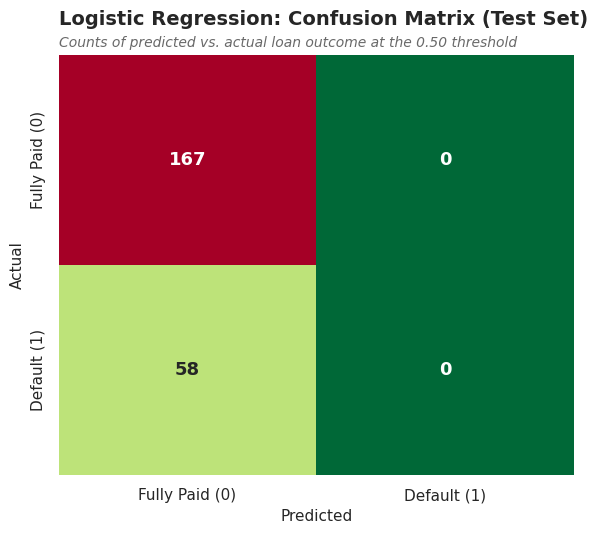

In [8]:
fig = model_utils.plot_confusion_matrix_chart(
    y_test, (result_logistic_regression.y_proba_test >= 0.5).astype(int),
    title=f"Logistic Regression: Confusion Matrix (Test Set)",
    subtitle="Counts of predicted vs. actual loan outcome at the 0.50 threshold",
)
plt.show()


**Business interpretation:** the bottom-right and top-left cells are
correct calls; the bottom-left cell (predicted "Fully Paid" but actually
defaulted) is the costly miss the business most wants to shrink, while
the top-right cell (predicted "Default" but actually paid) represents
good customers turned away.

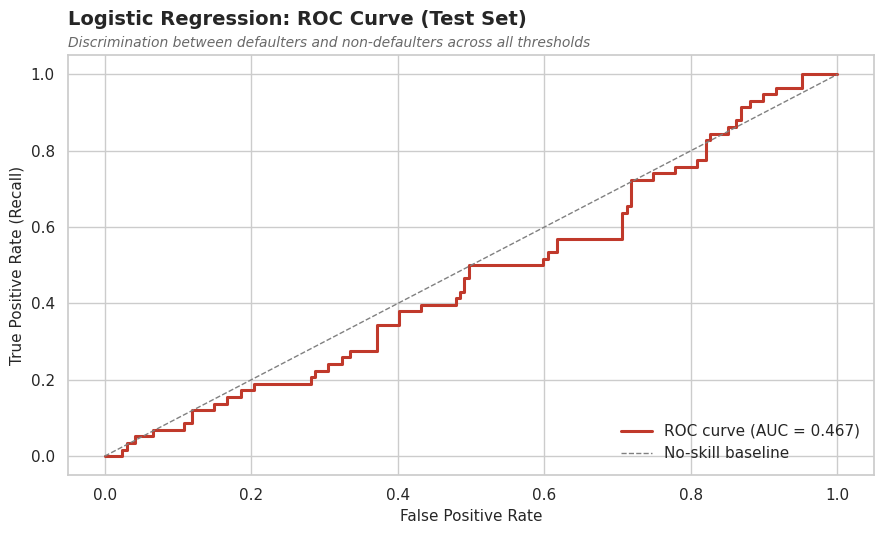

In [9]:
fig = model_utils.plot_roc_curve_chart(
    y_test, result_logistic_regression.y_proba_test,
    title=f"Logistic Regression: ROC Curve (Test Set)",
    subtitle="Discrimination between defaulters and non-defaulters across all thresholds",
)
plt.show()


**Business interpretation:** the further the curve bows toward the
top-left corner (away from the diagonal no-skill line), the better the
model separates future defaulters from future good borrowers regardless
of which threshold is ultimately chosen.

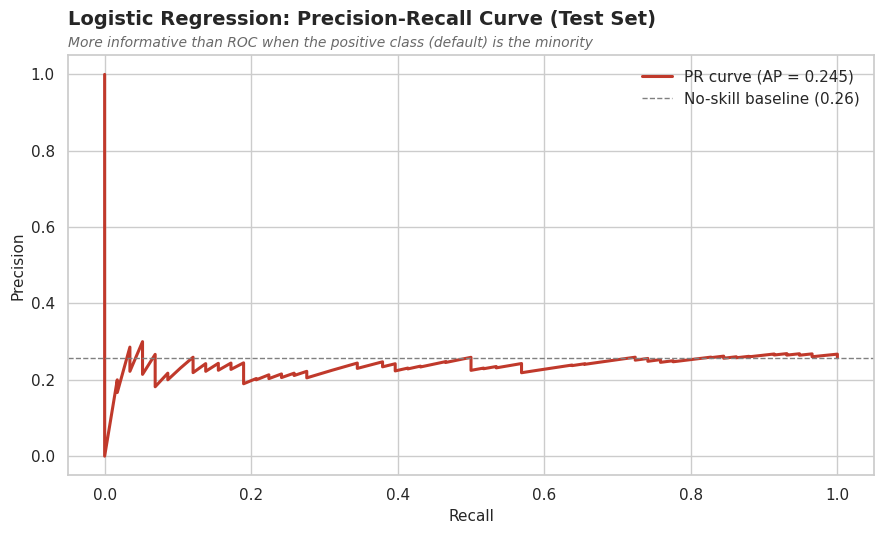

In [10]:
fig = model_utils.plot_pr_curve_chart(
    y_test, result_logistic_regression.y_proba_test,
    title=f"Logistic Regression: Precision-Recall Curve (Test Set)",
    subtitle="More informative than ROC when the positive class (default) is the minority",
)
plt.show()


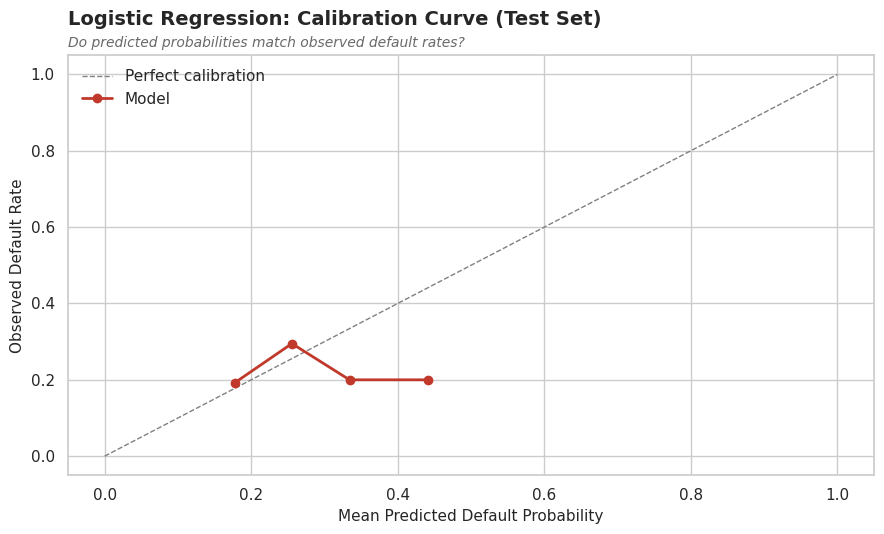

In [11]:
fig = model_utils.plot_calibration_curve_chart(
    y_test, result_logistic_regression.y_proba_test,
    title=f"Logistic Regression: Calibration Curve (Test Set)",
    subtitle="Do predicted probabilities match observed default rates?",
)
plt.show()


**Business interpretation:** points on the diagonal mean predicted
probabilities can be taken at face value (e.g. used directly for
risk-based pricing); points below the diagonal mean the model
over-states risk in that probability range, points above mean it
under-states risk.

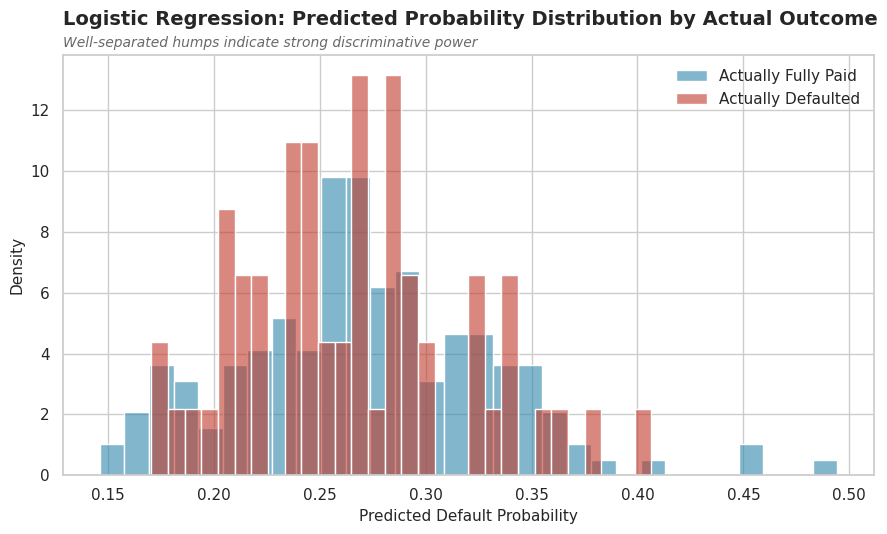

In [12]:
fig = model_utils.plot_probability_distribution_chart(
    y_test, result_logistic_regression.y_proba_test,
    title=f"Logistic Regression: Predicted Probability Distribution by Actual Outcome",
    subtitle="Well-separated humps indicate strong discriminative power",
)
plt.show()


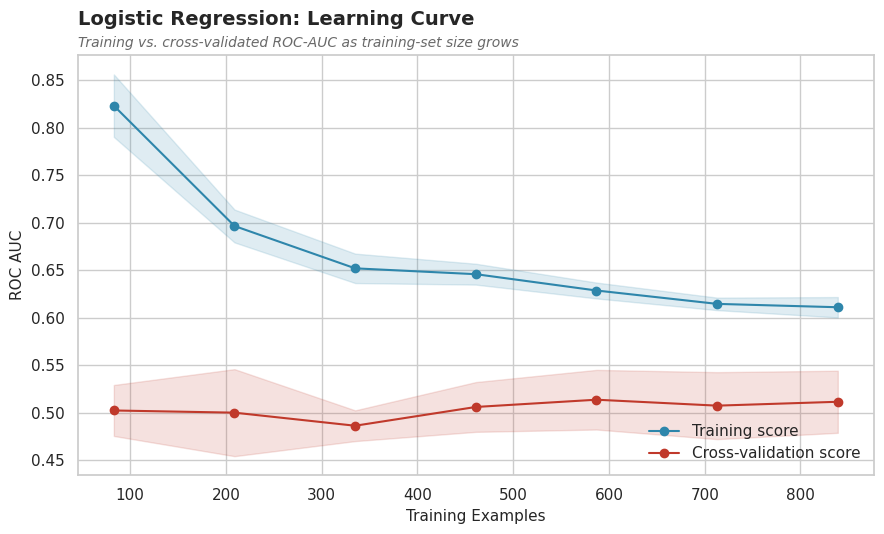

In [13]:
fig = model_utils.plot_learning_curve_chart(
    result_logistic_regression.best_estimator, X_train, y_train,
    title=f"Logistic Regression: Learning Curve",
    subtitle="Training vs. cross-validated ROC-AUC as training-set size grows",
)
plt.show()


**Business interpretation:** a persistent, wide gap between the
training and cross-validation lines indicates high variance (the model
is overfitting the training data — more data or stronger regularization
would likely help); both lines converging at a low score instead
indicates high bias (the model is too simple/constrained for the
signal available — more data alone would not help much).

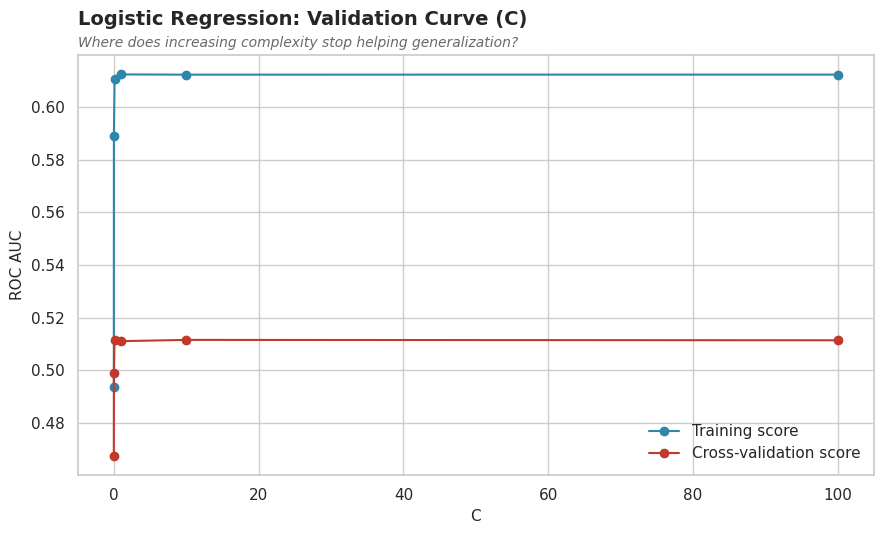

In [14]:
fig = model_utils.plot_validation_curve_chart(
    result_logistic_regression.best_estimator, X_train, y_train,
    param_name="classifier__C",
    param_range=[0.001, 0.01, 0.1, 1, 10, 100],
    title=f"Logistic Regression: Validation Curve (C)",
    subtitle="Where does increasing complexity stop helping generalization?",
)
plt.show()


**Business interpretation:** the point where the cross-validation
line plateaus or turns down while the training line keeps climbing marks
where `C` starts
overfitting rather than improving genuine predictive power — a practical
ceiling for that hyperparameter beyond the one the search already found.

### Logistic Regression: Feature Importance

In [15]:
coef_table = result_logistic_regression.feature_importance["coefficients"]
coef_table.head(15)


,feature,coefficient,odds_ratio
0,onehot_categorical__purpose_debt_consolidation,-0.2379,0.7883
1,onehot_categorical__term_ 36 months,-0.2205,0.8022
2,onehot_categorical__home_ownership_MORTGAGE,-0.2128,0.8083
3,onehot_categorical__home_ownership_RENT,-0.2085,0.8118
4,onehot_categorical__application_type_Joint App,-0.2011,0.8178
5,onehot_categorical__verification_status_Verified,-0.1922,0.8251
6,onehot_categorical__initial_list_status_w,-0.1692,0.8443
7,onehot_categorical__initial_list_status_f,-0.1532,0.8580
8,onehot_categorical__purpose_other,-0.1467,0.8635
9,numeric__revol_bal,-0.1216,0.8855


**Interpretation:** for a one-unit increase in a standardized
numeric feature (or moving into a one-hot category), the odds of default
multiply by the odds ratio — e.g. an odds ratio of 1.20 means a 20%
increase in the odds of default; 0.80 means a 20% decrease. The
strongest positive predictors (odds ratio > 1) increase default risk;
the strongest negative predictors (odds ratio < 1) are protective.

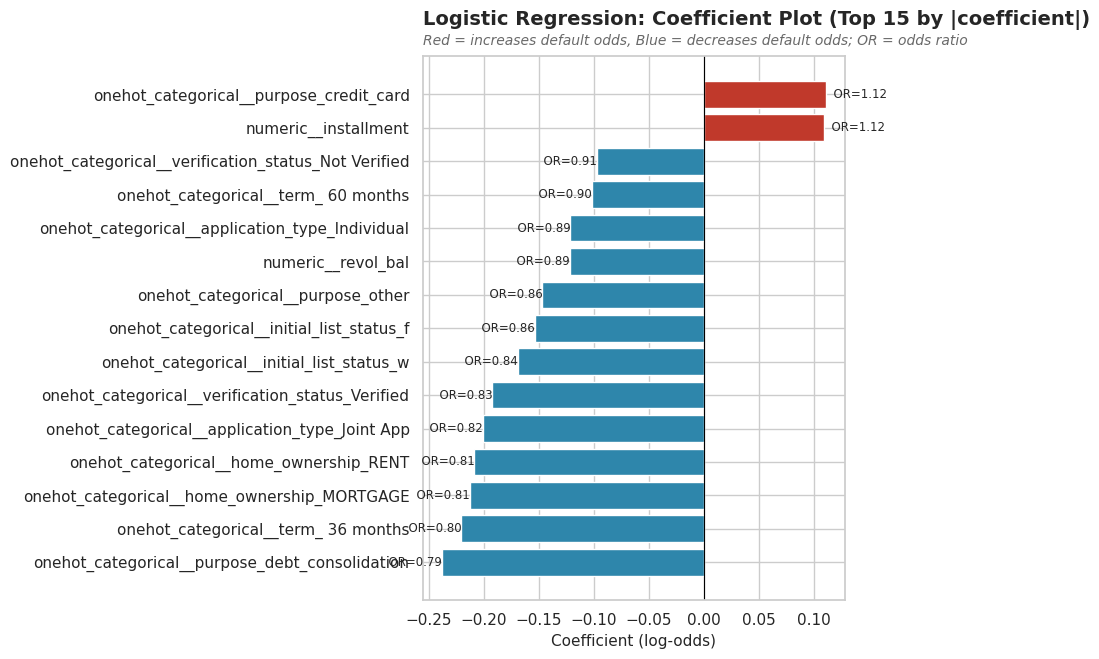

In [16]:
fig = model_utils.plot_coefficient_chart(
    coef_table, title=f"Logistic Regression: Coefficient Plot (Top 15 by |coefficient|)",
    subtitle="Red = increases default odds, Blue = decreases default odds; OR = odds ratio",
)
plt.show()


In [17]:
perm_table = result_logistic_regression.feature_importance["permutation"]
perm_table.head(10)


,feature,importance_mean,importance_std
0,purpose,0.0198,0.0131
1,loan_amnt,0.0141,0.0112
2,verification_status,0.0100,0.0063
3,int_rate,0.0097,0.0089
4,home_ownership,0.0091,0.0066
5,pub_rec_bankruptcies,0.0079,0.0065
6,dti,0.0067,0.0103
7,annual_inc,0.0033,0.0060
8,open_acc,0.0029,0.0090
9,installment,0.0017,0.0150


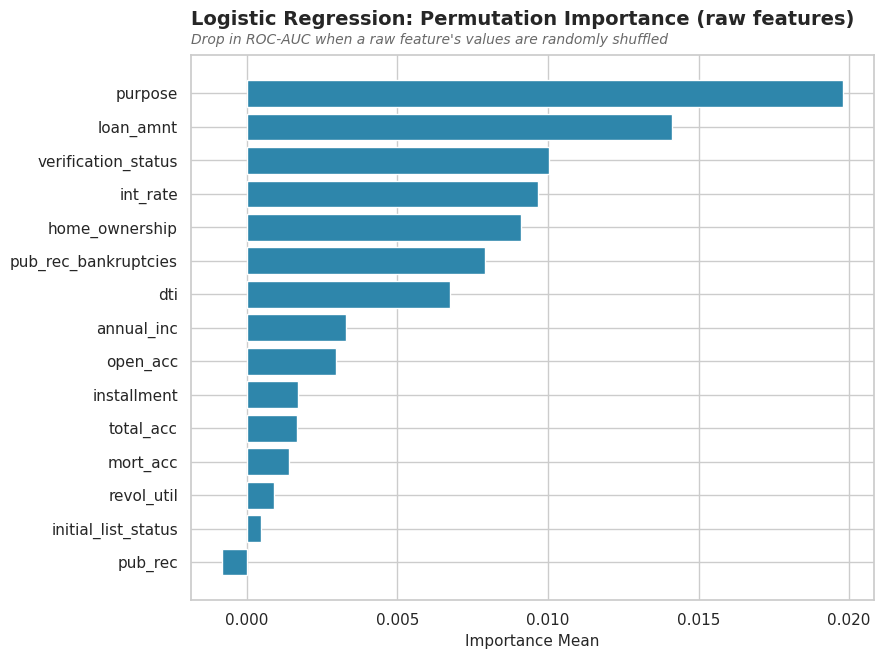

In [18]:
fig = model_utils.plot_importance_bar(
    perm_table, value_column="importance_mean",
    title=f"Logistic Regression: Permutation Importance (raw features)",
    subtitle="Drop in ROC-AUC when a raw feature's values are randomly shuffled",
)
plt.show()


### Logistic Regression: Threshold Analysis

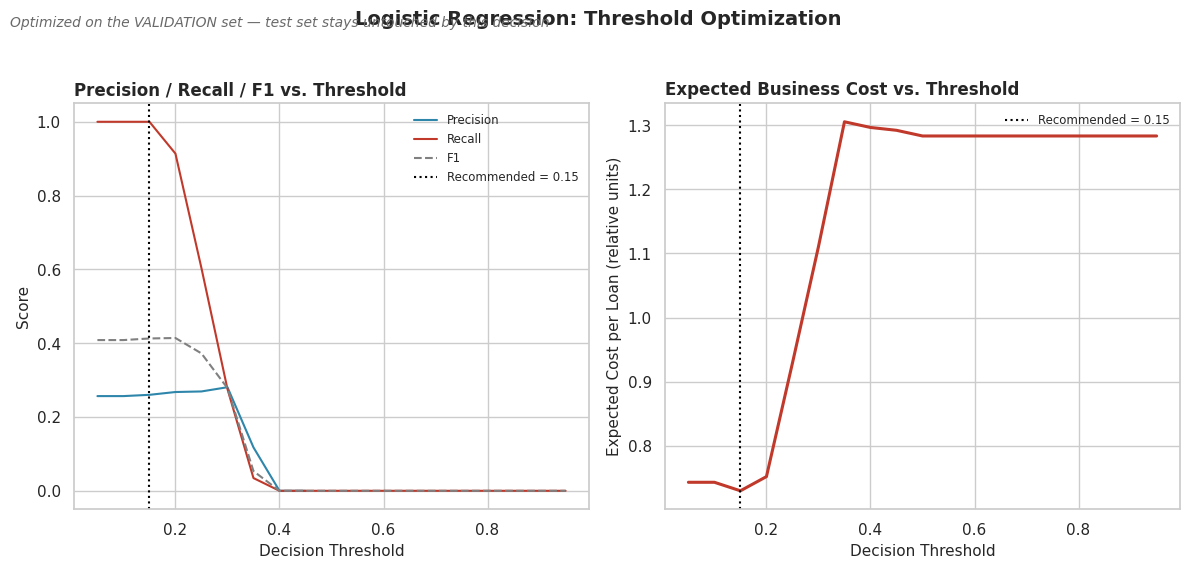

Recommended threshold: 0.15


In [19]:
fig = model_utils.plot_threshold_analysis_chart(
    result_logistic_regression.threshold_table, result_logistic_regression.recommended_threshold,
    title=f"Logistic Regression: Threshold Optimization",
    subtitle="Optimized on the VALIDATION set — test set stays untouched by this decision",
)
plt.show()
print(f"Recommended threshold: {result_logistic_regression.recommended_threshold:.2f}")


### Logistic Regression: Executive Summary

- **What did we discover?** Compare `result_logistic_regression`'s test ROC-AUC/
  F1/recall (printed above) against the other two models once all three
  sections have run, and note the CV mean ± std stability from the
  cross-validation table.
- **Why does it matter?** The confusion-matrix cost balance (missed
  defaulters vs. wrongly declined good borrowers) for Logistic Regression
  reflects its interpretability/complexity tradeoff described in
  Section 2.
- **How should Lending Club use this information?** Whether
  Logistic Regression is better suited to policy explanation, a supporting
  model in an ensemble, or the primary production scorer is addressed in
  Section 7's comparison table and Section 8's recommendation.
- **Which research question(s) does it address?** Research Questions 1
  ("which borrower characteristics appear associated with default") and
  2 ("do LendingClub grades appear predictive") most directly, via the
  feature-importance table above.


## 5. Random Forest

**Why this algorithm:** an ensemble of decision trees (via bagging) that
captures nonlinear relationships and feature interactions (e.g. "high
DTI matters more when income is also low") without hand-engineering
them, while still offering intuitive impurity-based and permutation
feature importances.

**Advantages:** handles nonlinearity/interactions natively, robust to
outliers and unscaled features, low risk of severe overfitting thanks to
bagging, minimal preprocessing requirements.

**Disadvantages:** individual trees are uninterpretable (the ensemble
offers importance measures, not "why this one borrower" — that gap is
exactly what Phase 4's SHAP analysis will close); larger memory
footprint than a single linear model; impurity importance is biased
toward high-cardinality numeric features.

**Business tradeoff:** meaningfully better discrimination potential than
Logistic Regression at the cost of some interpretability and larger
serialized model size.

**Computational complexity:** O(n_trees × n_samples × log(n_samples) ×
n_features) for training; prediction is O(n_trees × tree_depth) — fast,
but slower than a single logistic regression scoring pass.

**Hyperparameter search space**
(`config.RANDOM_FOREST_PARAM_DISTRIBUTIONS`, searched via
`RandomizedSearchCV` with `n_iter=20` — see Section 2 for why randomized
rather than grid search is used here):
- `n_estimators` ∈ {200, 300, 400, 500} — more trees generally reduce
  variance but with diminishing returns past a point.
- `max_depth` ∈ {4, 6, 8, 10, 12, 16, None} — controls how much each
  tree can overfit individually.
- `min_samples_split`, `min_samples_leaf` — additional overfitting
  controls at the leaf level.
- `max_features` ∈ {"sqrt", "log2", 0.5} — how many features each split
  considers, which decorrelates trees from one another.
- `class_weight` ∈ {None, "balanced", "balanced_subsample"} — tests
  minority-class rebalancing strategies.


In [20]:
result_random_forest = model_utils.train_and_evaluate_model(
    "random_forest", X_train, y_train, X_val, y_val, X_test, y_test,
)
print(f"Best params: {result_random_forest.best_params}")


2026-08-02 19:30:46 | INFO     | src.model_utils | ======================================================================


2026-08-02 19:30:46 | INFO     | src.model_utils | Training and evaluating: Random Forest


2026-08-02 19:30:46 | INFO     | src.model_utils | ======================================================================


2026-08-02 19:30:46 | INFO     | src.utils | Built preprocessing ColumnTransformer: 14 numeric, 6 one-hot, 1 ordinal features.


2026-08-02 19:30:46 | INFO     | src.model_utils | Starting RandomizedSearchCV with n_iter=20.


2026-08-02 19:32:42 | INFO     | src.model_utils | RandomizedSearchCV complete in 115.59s. Best roc_auc=0.5322. Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 8, 'classifier__max_features': 'log2', 'classifier__max_depth': 16, 'classifier__class_weight': 'balanced_subsample'}


2026-08-02 19:32:48 | INFO     | src.model_utils | Random Forest complete. Test ROC-AUC=0.4975 | Recommended threshold=0.30 | Training time=0.574s | Search time=115.6s


Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 8, 'classifier__max_features': 'log2', 'classifier__max_depth': 16, 'classifier__class_weight': 'balanced_subsample'}


### Random Forest: Cross-Validation Results

Fold-by-fold `config.CV_SCORING` for the best hyperparameter
combination found by the search, plus the mean and standard deviation
across the `config.CV_FOLDS` folds.

In [21]:
result_random_forest.cv_fold_results


,fold,roc_auc
0,1,0.5451
1,2,0.5611
2,3,0.4953
3,4,0.5027
4,5,0.5566
5,mean,0.5322
6,std,0.0277


### Random Forest: Evaluation Metrics (Test Set)

Computed at the default 0.50 threshold for like-for-like comparison
across models (Section 6 revisits the recommended, cost-minimizing
threshold instead).

In [22]:
pd.Series(result_random_forest.test_metrics, name="random_forest").to_frame()


,random_forest
accuracy,0.7022
precision,0.3043
recall,0.1207
specificity,0.9042
f1_score,0.1728
roc_auc,0.4975
average_precision,0.2859
balanced_accuracy,0.5124
matthews_corrcoef,0.0359
log_loss,0.6325


### Random Forest: Train / Validation / Test Comparison (Overfitting Check)

Comparing ROC-AUC across the three splits at the same 0.50 threshold —
a large train-vs-validation/test gap signals overfitting (high
variance); uniformly low scores across all three signal underfitting
(high bias).

In [23]:
pd.DataFrame({
    "train": result_random_forest.train_metrics,
    "validation": result_random_forest.val_metrics,
    "test": result_random_forest.test_metrics,
}).T[["roc_auc", "f1_score", "recall", "precision", "log_loss"]]


,roc_auc,f1_score,recall,precision,log_loss
train,0.9959,0.9412,0.9185,0.9650,0.4771
validation,0.4605,0.1299,0.0862,0.2632,0.6349
test,0.4975,0.1728,0.1207,0.3043,0.6325


### Random Forest: Diagnostic Visualizations

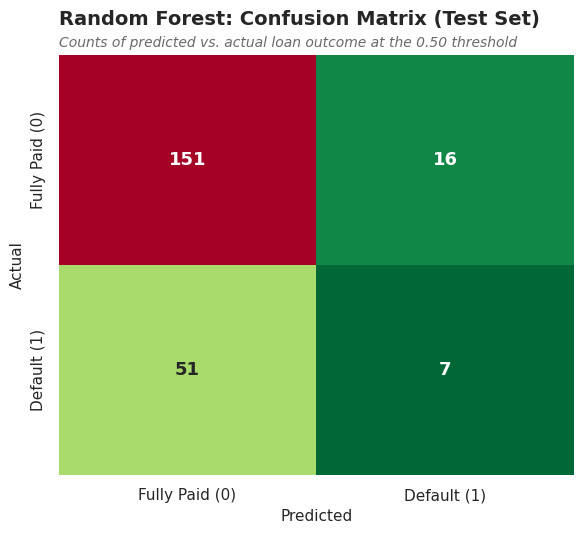

In [24]:
fig = model_utils.plot_confusion_matrix_chart(
    y_test, (result_random_forest.y_proba_test >= 0.5).astype(int),
    title=f"Random Forest: Confusion Matrix (Test Set)",
    subtitle="Counts of predicted vs. actual loan outcome at the 0.50 threshold",
)
plt.show()


**Business interpretation:** the bottom-right and top-left cells are
correct calls; the bottom-left cell (predicted "Fully Paid" but actually
defaulted) is the costly miss the business most wants to shrink, while
the top-right cell (predicted "Default" but actually paid) represents
good customers turned away.

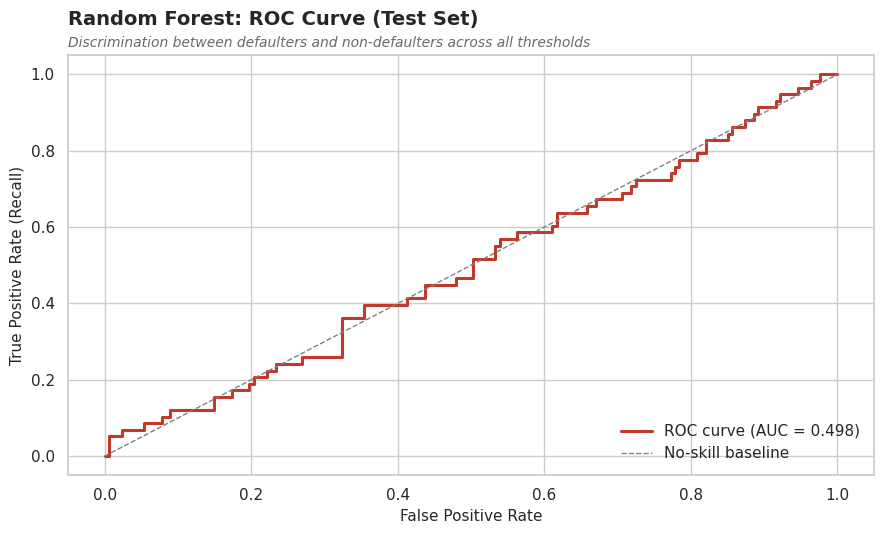

In [25]:
fig = model_utils.plot_roc_curve_chart(
    y_test, result_random_forest.y_proba_test,
    title=f"Random Forest: ROC Curve (Test Set)",
    subtitle="Discrimination between defaulters and non-defaulters across all thresholds",
)
plt.show()


**Business interpretation:** the further the curve bows toward the
top-left corner (away from the diagonal no-skill line), the better the
model separates future defaulters from future good borrowers regardless
of which threshold is ultimately chosen.

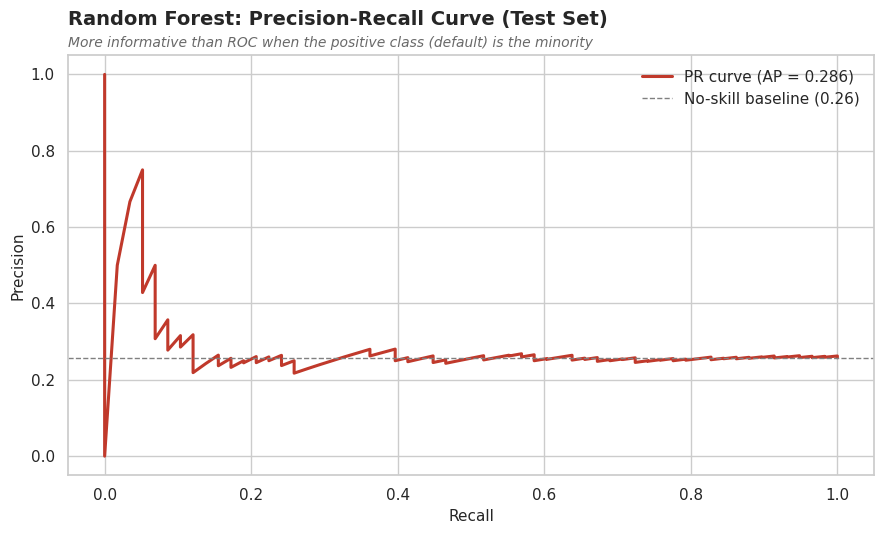

In [26]:
fig = model_utils.plot_pr_curve_chart(
    y_test, result_random_forest.y_proba_test,
    title=f"Random Forest: Precision-Recall Curve (Test Set)",
    subtitle="More informative than ROC when the positive class (default) is the minority",
)
plt.show()


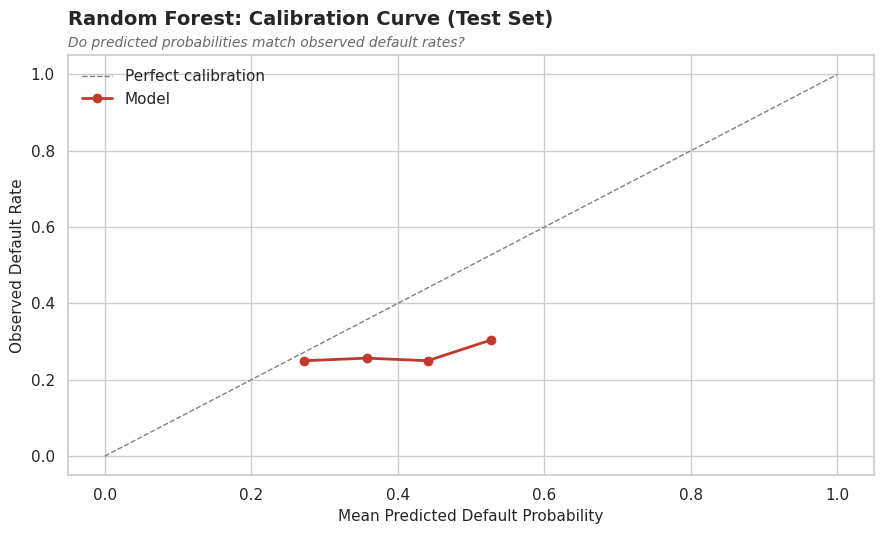

In [27]:
fig = model_utils.plot_calibration_curve_chart(
    y_test, result_random_forest.y_proba_test,
    title=f"Random Forest: Calibration Curve (Test Set)",
    subtitle="Do predicted probabilities match observed default rates?",
)
plt.show()


**Business interpretation:** points on the diagonal mean predicted
probabilities can be taken at face value (e.g. used directly for
risk-based pricing); points below the diagonal mean the model
over-states risk in that probability range, points above mean it
under-states risk.

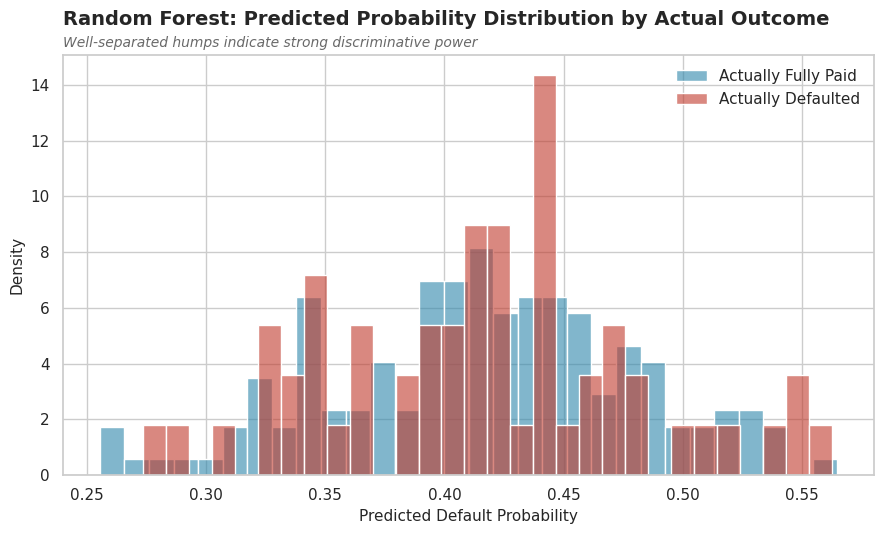

In [28]:
fig = model_utils.plot_probability_distribution_chart(
    y_test, result_random_forest.y_proba_test,
    title=f"Random Forest: Predicted Probability Distribution by Actual Outcome",
    subtitle="Well-separated humps indicate strong discriminative power",
)
plt.show()


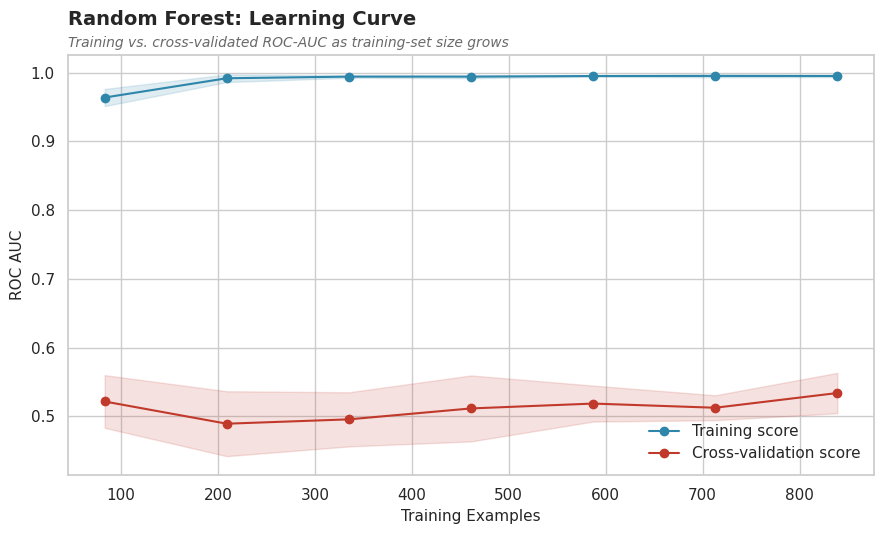

In [29]:
fig = model_utils.plot_learning_curve_chart(
    result_random_forest.best_estimator, X_train, y_train,
    title=f"Random Forest: Learning Curve",
    subtitle="Training vs. cross-validated ROC-AUC as training-set size grows",
)
plt.show()


**Business interpretation:** a persistent, wide gap between the
training and cross-validation lines indicates high variance (the model
is overfitting the training data — more data or stronger regularization
would likely help); both lines converging at a low score instead
indicates high bias (the model is too simple/constrained for the
signal available — more data alone would not help much).

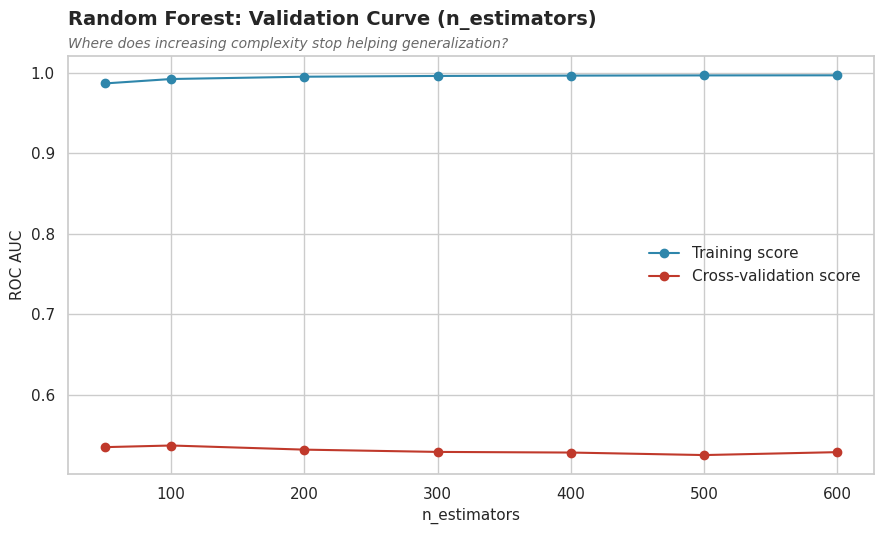

In [30]:
fig = model_utils.plot_validation_curve_chart(
    result_random_forest.best_estimator, X_train, y_train,
    param_name="classifier__n_estimators",
    param_range=[50, 100, 200, 300, 400, 500, 600],
    title=f"Random Forest: Validation Curve (n_estimators)",
    subtitle="Where does increasing complexity stop helping generalization?",
)
plt.show()


**Business interpretation:** the point where the cross-validation
line plateaus or turns down while the training line keeps climbing marks
where `n_estimators` starts
overfitting rather than improving genuine predictive power — a practical
ceiling for that hyperparameter beyond the one the search already found.

### Random Forest: Feature Importance

In [31]:
impurity_table = result_random_forest.feature_importance["impurity"]
impurity_table.head(15)


,feature,importance
0,numeric__int_rate,0.0990
1,numeric__dti,0.0927
2,numeric__installment,0.0859
3,numeric__revol_bal,0.0849
4,numeric__annual_inc,0.0799
5,numeric__revol_util,0.0795
6,numeric__loan_amnt,0.0734
7,numeric__total_acc,0.0642
8,numeric__open_acc,0.0633
9,numeric__emp_length_years,0.0529


**Caveat:** impurity importance is biased toward high-cardinality /
continuous numeric features and can overstate importance for features
with many possible split points — permutation importance below is
computed as a cross-check.

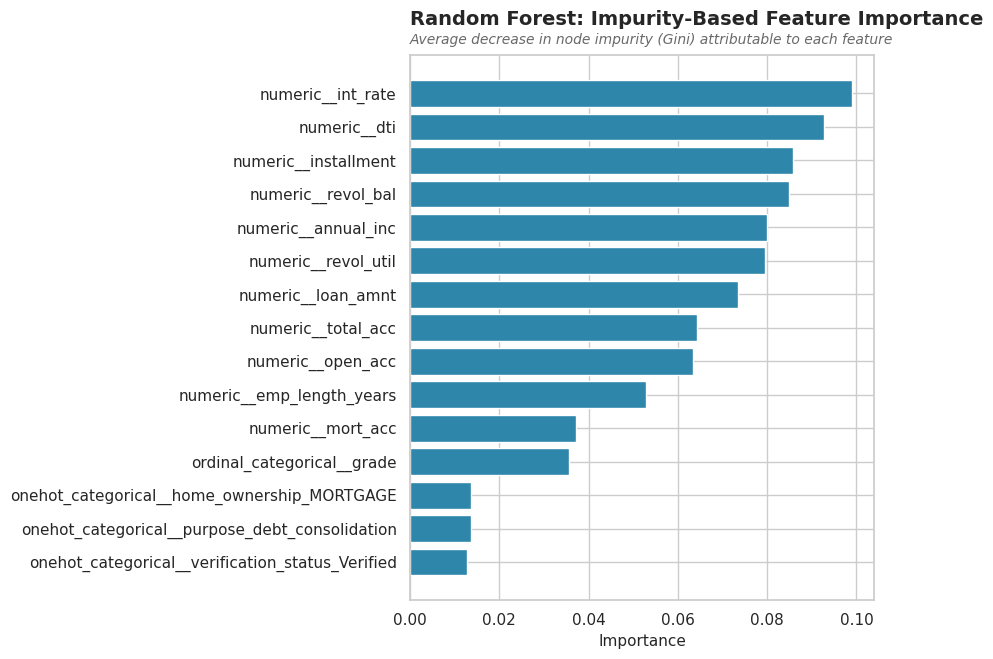

In [32]:
fig = model_utils.plot_importance_bar(
    impurity_table, value_column="importance",
    title=f"Random Forest: Impurity-Based Feature Importance",
    subtitle="Average decrease in node impurity (Gini) attributable to each feature",
)
plt.show()


In [33]:
perm_table = result_random_forest.feature_importance["permutation"]
perm_table.head(15)


,feature,importance_mean,importance_std
0,total_acc,0.0180,0.0074
1,home_ownership,0.0081,0.0053
2,verification_status,0.0071,0.0075
3,purpose,0.0063,0.0075
4,int_rate,0.0056,0.0291
5,annual_inc,0.0048,0.0109
6,initial_list_status,0.0033,0.0039
7,emp_length_years,0.0032,0.0070
8,pub_rec,0.0028,0.0029
9,revol_util,0.0020,0.0071


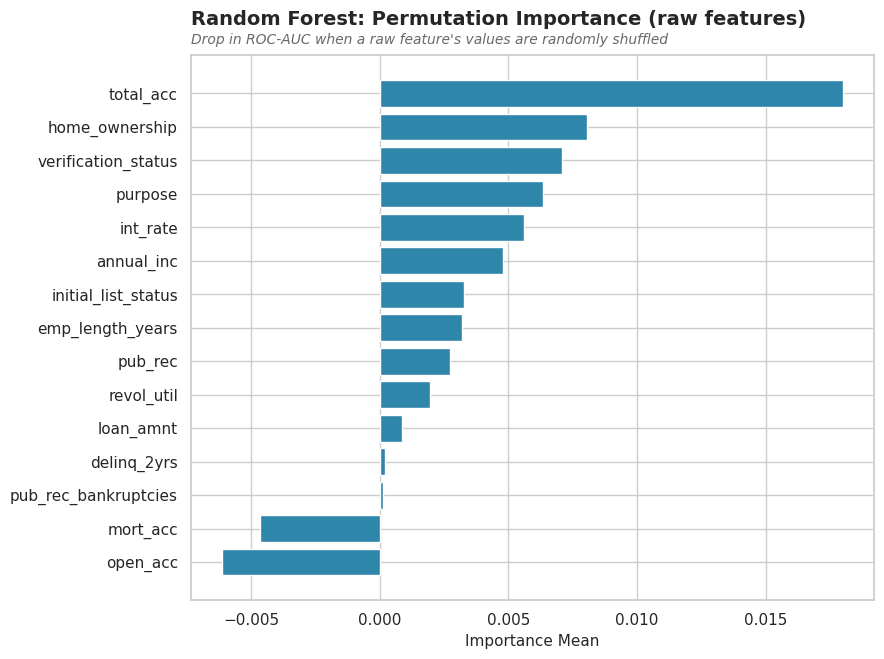

In [34]:
fig = model_utils.plot_importance_bar(
    perm_table, value_column="importance_mean",
    title=f"Random Forest: Permutation Importance (raw features)",
    subtitle="Drop in ROC-AUC when a raw feature's values are randomly shuffled",
)
plt.show()


In [35]:
comparison = impurity_table.merge(
    perm_table, on="feature", how="outer"
).sort_values("importance_mean", ascending=False)
comparison[["feature", "importance", "importance_mean"]].rename(
    columns={"importance": "impurity_importance", "importance_mean": "permutation_importance"}
).head(10)


,feature,impurity_importance,permutation_importance
53,total_acc,NaN,0.0180
6,home_ownership,NaN,0.0081
54,verification_status,NaN,0.0071
49,purpose,NaN,0.0063
9,int_rate,NaN,0.0056
0,annual_inc,NaN,0.0048
7,initial_list_status,NaN,0.0033
4,emp_length_years,NaN,0.0032
47,pub_rec,NaN,0.0028
51,revol_util,NaN,0.0020


**Comparing the two methods:** features that rank highly under BOTH
impurity and permutation importance are the most trustworthy candidates
for "truly predictive" — a feature high on impurity but low on
permutation importance is a signal of the impurity-bias caveat above
(often a high-cardinality numeric column that gets many candidate splits
without necessarily carrying unique predictive signal).

### Random Forest: Threshold Analysis

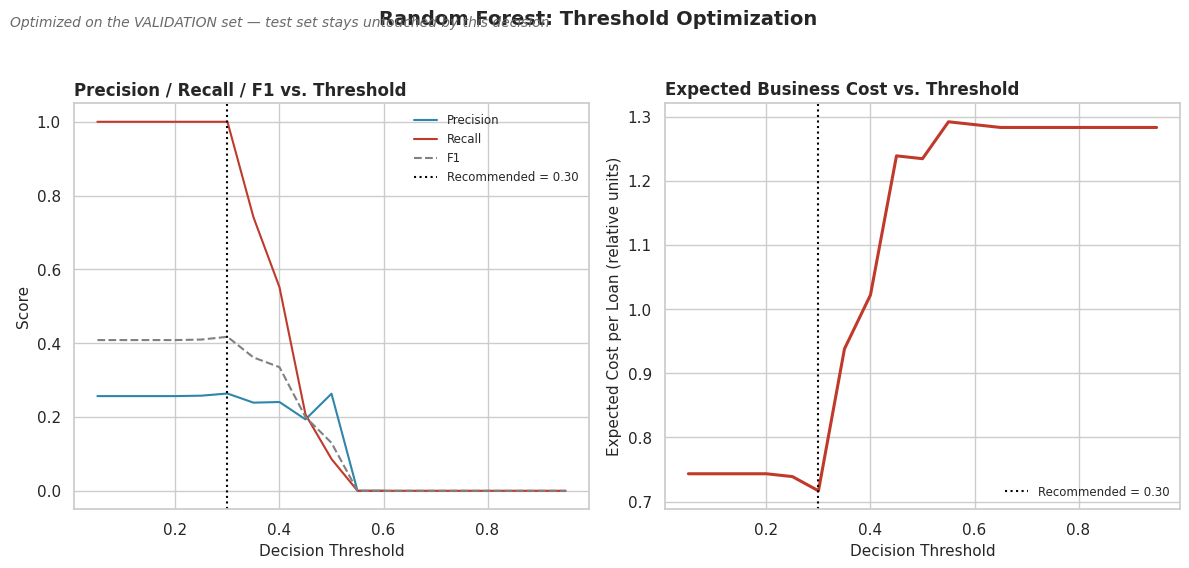

Recommended threshold: 0.30


In [36]:
fig = model_utils.plot_threshold_analysis_chart(
    result_random_forest.threshold_table, result_random_forest.recommended_threshold,
    title=f"Random Forest: Threshold Optimization",
    subtitle="Optimized on the VALIDATION set — test set stays untouched by this decision",
)
plt.show()
print(f"Recommended threshold: {result_random_forest.recommended_threshold:.2f}")


### Random Forest: Executive Summary

- **What did we discover?** Compare `result_random_forest`'s test ROC-AUC/
  F1/recall (printed above) against the other two models once all three
  sections have run, and note the CV mean ± std stability from the
  cross-validation table.
- **Why does it matter?** The confusion-matrix cost balance (missed
  defaulters vs. wrongly declined good borrowers) for Random Forest
  reflects its interpretability/complexity tradeoff described in
  Section 2.
- **How should Lending Club use this information?** Whether
  Random Forest is better suited to policy explanation, a supporting
  model in an ensemble, or the primary production scorer is addressed in
  Section 7's comparison table and Section 8's recommendation.
- **Which research question(s) does it address?** Research Questions 1
  ("which borrower characteristics appear associated with default") and
  2 ("do LendingClub grades appear predictive") most directly, via the
  feature-importance table above.


## 6. XGBoost

**Why this algorithm:** gradient-boosted trees trained sequentially,
each new tree correcting the previous ensemble's residual errors, which
typically yields the strongest raw discriminative performance among
tree-based methods on structured/tabular data — making it the candidate
production model.

**Advantages:** state-of-the-art tabular performance, built-in
regularization (L1/L2, `min_child_weight`, `gamma`) that helps control
overfitting, native handling of missing values, fast histogram-based
split finding, multiple importance views (gain/weight/cover).

**Disadvantages:** the largest hyperparameter surface of the three
(highest tuning cost), least directly interpretable without an
additional layer (SHAP, Phase 4), can overfit small/noisy datasets if
not regularized carefully.

**Business tradeoff:** typically the best accuracy/ROC-AUC of the
three, at the cost of being a "black box" without supplementary
explainability tooling and a heavier tuning/maintenance burden.

**Computational complexity:** O(n_trees × n_samples × n_features ×
log(n_samples)) for training (similar order to Random Forest, but
sequential across trees rather than independent/parallel, though each
tree's construction is itself parallelized internally).

**Hyperparameter search space** (`config.XGBOOST_PARAM_DISTRIBUTIONS`,
extended at runtime with a data-driven `scale_pos_weight` candidate —
see `model_utils._xgboost_param_distributions` — and searched via
`RandomizedSearchCV` with `n_iter=30`):
- `n_estimators`, `max_depth`, `learning_rate` — the core boosting
  triad: how many trees, how complex each one, how much each one
  contributes.
- `subsample`, `colsample_bytree` — row/column subsampling per tree,
  which reduces overfitting and correlation between trees (similar
  spirit to Random Forest's `max_features`).
- `min_child_weight`, `gamma` — minimum leaf weight / minimum split
  loss reduction required to make a split, both directly limiting tree
  complexity.
- `reg_alpha`, `reg_lambda` — L1/L2 regularization on leaf weights.
- `scale_pos_weight` ∈ {1.0, `negative_count/positive_count`} — tests
  whether explicitly reweighting the minority (default) class improves
  ranking quality, mirroring Random Forest's `class_weight` options.


In [37]:
result_xgboost = model_utils.train_and_evaluate_model(
    "xgboost", X_train, y_train, X_val, y_val, X_test, y_test,
)
print(f"Best params: {result_xgboost.best_params}")


2026-08-02 19:33:40 | INFO     | src.model_utils | ======================================================================


2026-08-02 19:33:40 | INFO     | src.model_utils | Training and evaluating: XGBoost


2026-08-02 19:33:40 | INFO     | src.model_utils | ======================================================================


2026-08-02 19:33:40 | INFO     | src.utils | Built preprocessing ColumnTransformer: 14 numeric, 6 one-hot, 1 ordinal features.


2026-08-02 19:33:40 | INFO     | src.model_utils | Starting RandomizedSearchCV with n_iter=30.


2026-08-02 19:34:15 | INFO     | src.model_utils | RandomizedSearchCV complete in 34.89s. Best roc_auc=0.5386. Best params: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 2.89, 'classifier__reg_lambda': 1.0, 'classifier__reg_alpha': 0.01, 'classifier__n_estimators': 450, 'classifier__min_child_weight': 7, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 0.6}


2026-08-02 19:34:17 | INFO     | src.model_utils | XGBoost complete. Test ROC-AUC=0.5560 | Recommended threshold=0.05 | Training time=0.196s | Search time=34.9s


Best params: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 2.89, 'classifier__reg_lambda': 1.0, 'classifier__reg_alpha': 0.01, 'classifier__n_estimators': 450, 'classifier__min_child_weight': 7, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 0.6}


### XGBoost: Cross-Validation Results

Fold-by-fold `config.CV_SCORING` for the best hyperparameter
combination found by the search, plus the mean and standard deviation
across the `config.CV_FOLDS` folds.

In [38]:
result_xgboost.cv_fold_results


,fold,roc_auc
0,1,0.5557
1,2,0.5583
2,3,0.5195
3,4,0.5294
4,5,0.5302
5,mean,0.5386
6,std,0.0155


### XGBoost: Evaluation Metrics (Test Set)

Computed at the default 0.50 threshold for like-for-like comparison
across models (Section 6 revisits the recommended, cost-minimizing
threshold instead).

In [39]:
pd.Series(result_xgboost.test_metrics, name="xgboost").to_frame()


,xgboost
accuracy,0.6533
precision,0.2826
recall,0.2241
specificity,0.8024
f1_score,0.2500
roc_auc,0.5560
average_precision,0.2949
balanced_accuracy,0.5133
matthews_corrcoef,0.0288
log_loss,0.7431


### XGBoost: Train / Validation / Test Comparison (Overfitting Check)

Comparing ROC-AUC across the three splits at the same 0.50 threshold —
a large train-vs-validation/test gap signals overfitting (high
variance); uniformly low scores across all three signal underfitting
(high bias).

In [40]:
pd.DataFrame({
    "train": result_xgboost.train_metrics,
    "validation": result_xgboost.val_metrics,
    "test": result_xgboost.test_metrics,
}).T[["roc_auc", "f1_score", "recall", "precision", "log_loss"]]


,roc_auc,f1_score,recall,precision,log_loss
train,1.0000,1.0000,1.0000,1.0000,0.0805
validation,0.4791,0.1188,0.1034,0.1395,0.8193
test,0.5560,0.2500,0.2241,0.2826,0.7431


### XGBoost: Diagnostic Visualizations

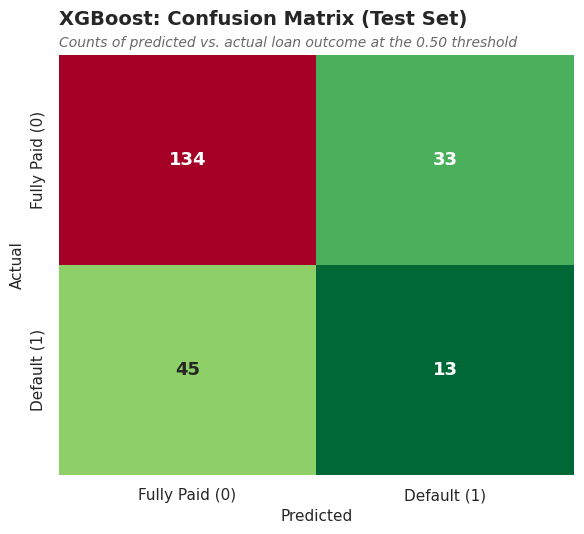

In [41]:
fig = model_utils.plot_confusion_matrix_chart(
    y_test, (result_xgboost.y_proba_test >= 0.5).astype(int),
    title=f"XGBoost: Confusion Matrix (Test Set)",
    subtitle="Counts of predicted vs. actual loan outcome at the 0.50 threshold",
)
plt.show()


**Business interpretation:** the bottom-right and top-left cells are
correct calls; the bottom-left cell (predicted "Fully Paid" but actually
defaulted) is the costly miss the business most wants to shrink, while
the top-right cell (predicted "Default" but actually paid) represents
good customers turned away.

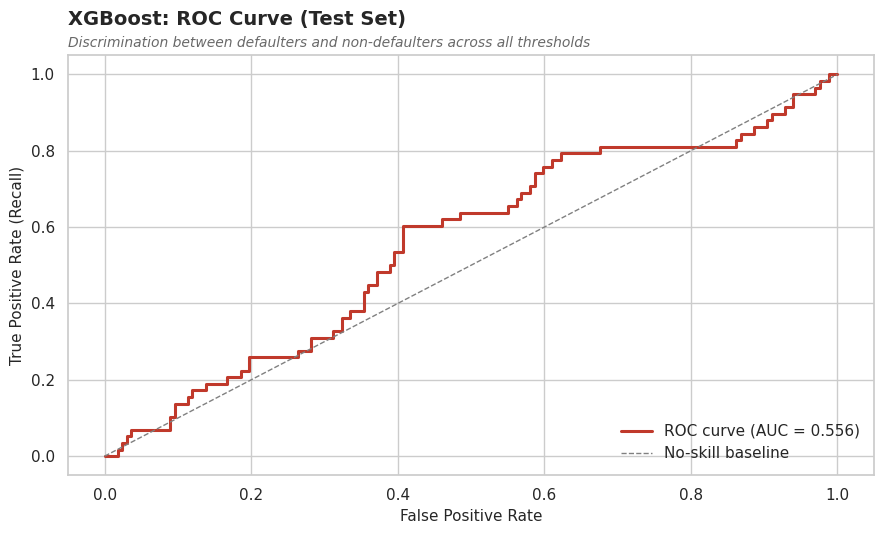

In [42]:
fig = model_utils.plot_roc_curve_chart(
    y_test, result_xgboost.y_proba_test,
    title=f"XGBoost: ROC Curve (Test Set)",
    subtitle="Discrimination between defaulters and non-defaulters across all thresholds",
)
plt.show()


**Business interpretation:** the further the curve bows toward the
top-left corner (away from the diagonal no-skill line), the better the
model separates future defaulters from future good borrowers regardless
of which threshold is ultimately chosen.

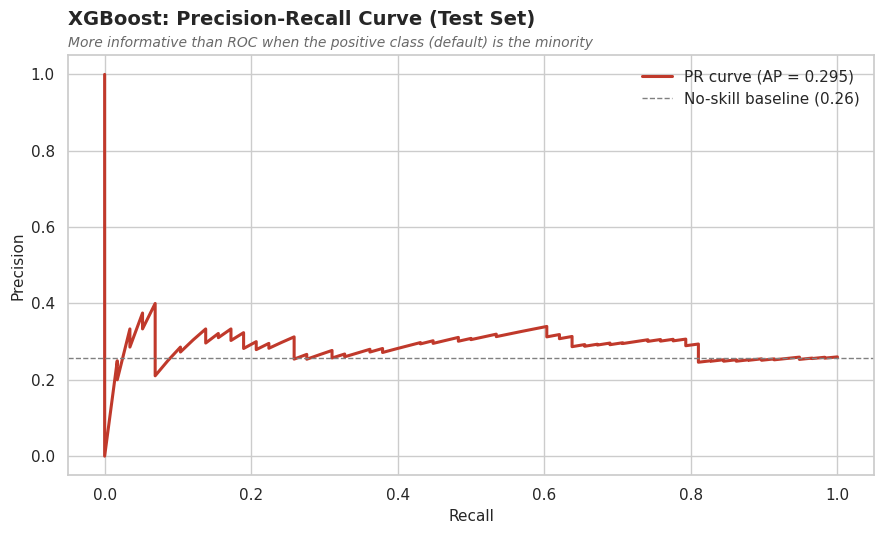

In [43]:
fig = model_utils.plot_pr_curve_chart(
    y_test, result_xgboost.y_proba_test,
    title=f"XGBoost: Precision-Recall Curve (Test Set)",
    subtitle="More informative than ROC when the positive class (default) is the minority",
)
plt.show()


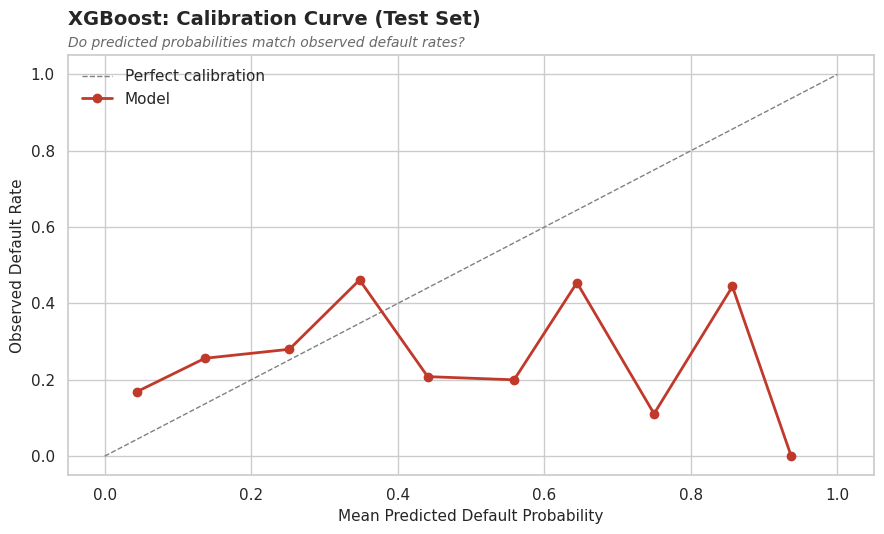

In [44]:
fig = model_utils.plot_calibration_curve_chart(
    y_test, result_xgboost.y_proba_test,
    title=f"XGBoost: Calibration Curve (Test Set)",
    subtitle="Do predicted probabilities match observed default rates?",
)
plt.show()


**Business interpretation:** points on the diagonal mean predicted
probabilities can be taken at face value (e.g. used directly for
risk-based pricing); points below the diagonal mean the model
over-states risk in that probability range, points above mean it
under-states risk.

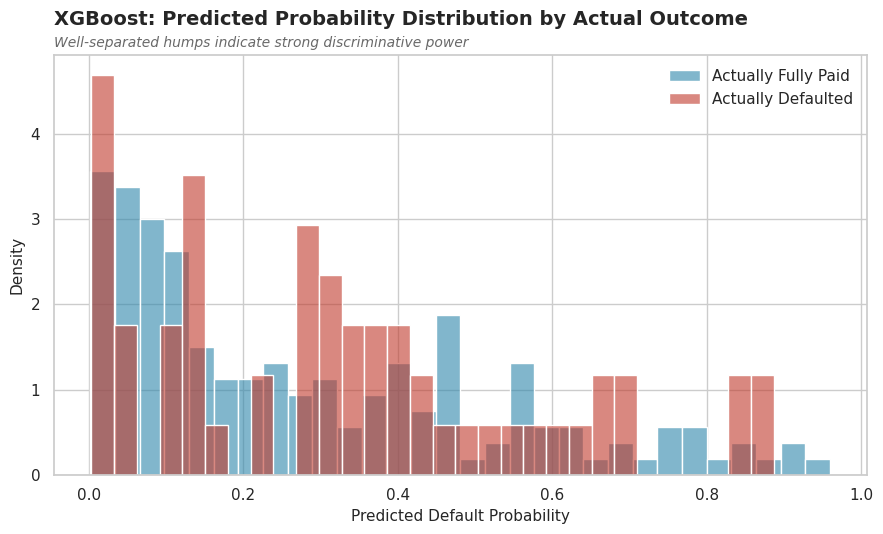

In [45]:
fig = model_utils.plot_probability_distribution_chart(
    y_test, result_xgboost.y_proba_test,
    title=f"XGBoost: Predicted Probability Distribution by Actual Outcome",
    subtitle="Well-separated humps indicate strong discriminative power",
)
plt.show()


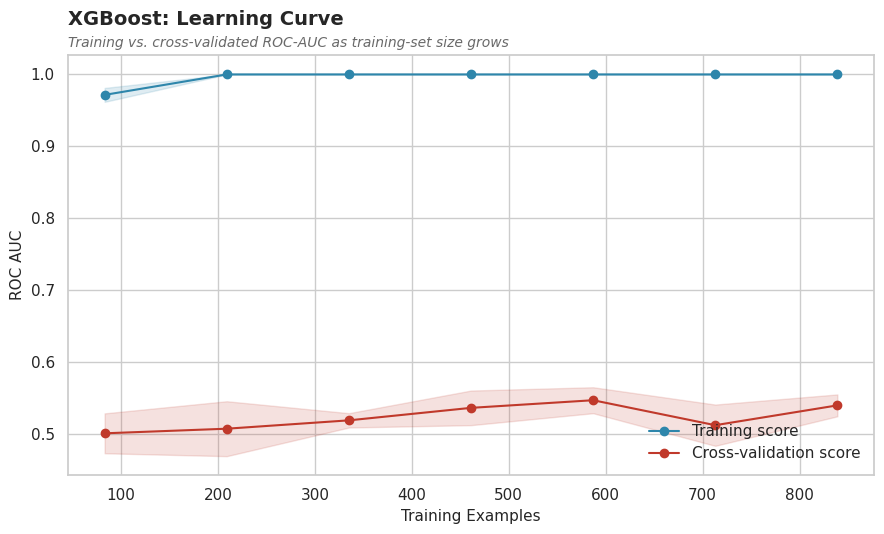

In [46]:
fig = model_utils.plot_learning_curve_chart(
    result_xgboost.best_estimator, X_train, y_train,
    title=f"XGBoost: Learning Curve",
    subtitle="Training vs. cross-validated ROC-AUC as training-set size grows",
)
plt.show()


**Business interpretation:** a persistent, wide gap between the
training and cross-validation lines indicates high variance (the model
is overfitting the training data — more data or stronger regularization
would likely help); both lines converging at a low score instead
indicates high bias (the model is too simple/constrained for the
signal available — more data alone would not help much).

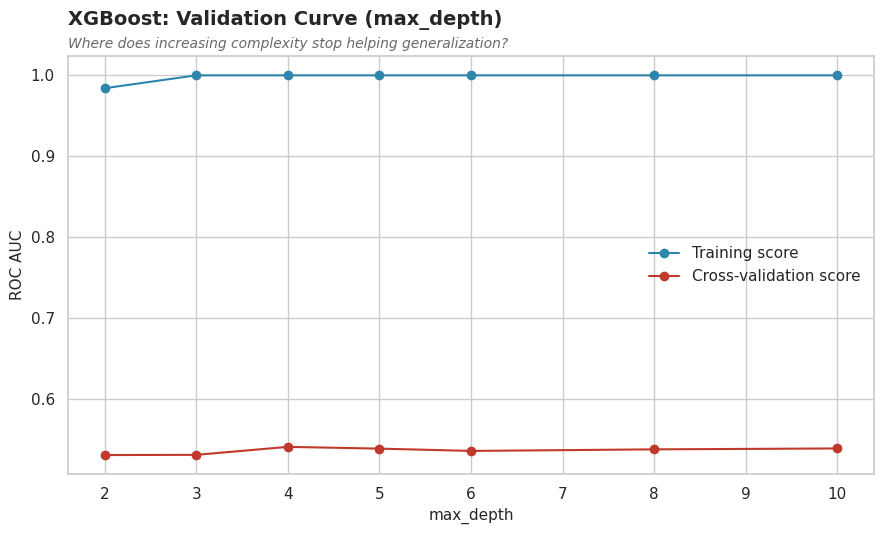

In [47]:
fig = model_utils.plot_validation_curve_chart(
    result_xgboost.best_estimator, X_train, y_train,
    param_name="classifier__max_depth",
    param_range=[2, 3, 4, 5, 6, 8, 10],
    title=f"XGBoost: Validation Curve (max_depth)",
    subtitle="Where does increasing complexity stop helping generalization?",
)
plt.show()


**Business interpretation:** the point where the cross-validation
line plateaus or turns down while the training line keeps climbing marks
where `max_depth` starts
overfitting rather than improving genuine predictive power — a practical
ceiling for that hyperparameter beyond the one the search already found.

### XGBoost: Feature Importance

In [48]:
gwc_table = result_xgboost.feature_importance["gain_weight_cover"]
gwc_table.head(15)


,feature,gain,weight,cover
0,numeric__pub_rec,5.1010,8.0000,87.0995
1,onehot_categorical__application_type_Individual,4.0950,8.0000,148.1992
2,onehot_categorical__purpose_major_purchase,3.8999,2.0000,206.9182
3,onehot_categorical__verification_status_Verified,3.7160,39.0000,45.5896
4,onehot_categorical__purpose_credit_card,3.2876,20.0000,96.9128
5,numeric__delinq_2yrs,2.9822,22.0000,50.1176
6,onehot_categorical__home_ownership_OWN,2.6948,10.0000,169.3302
7,numeric__dti,2.6205,500.0000,73.4129
8,numeric__revol_bal,2.5534,426.0000,64.0583
9,numeric__open_acc,2.5531,291.0000,69.5323


**The three XGBoost-native importance types:**
- **Gain** — average improvement in the loss function contributed by a
  feature; generally the most reliable single measure of "how much does
  this feature actually help predictions."
- **Weight** — how many times a feature is used to split across all
  trees; can overstate importance for features with many possible split
  points (the same caveat as Random Forest's impurity importance).
- **Cover** — average number of samples affected by splits on a
  feature; a proxy for how broadly a feature's splits apply.

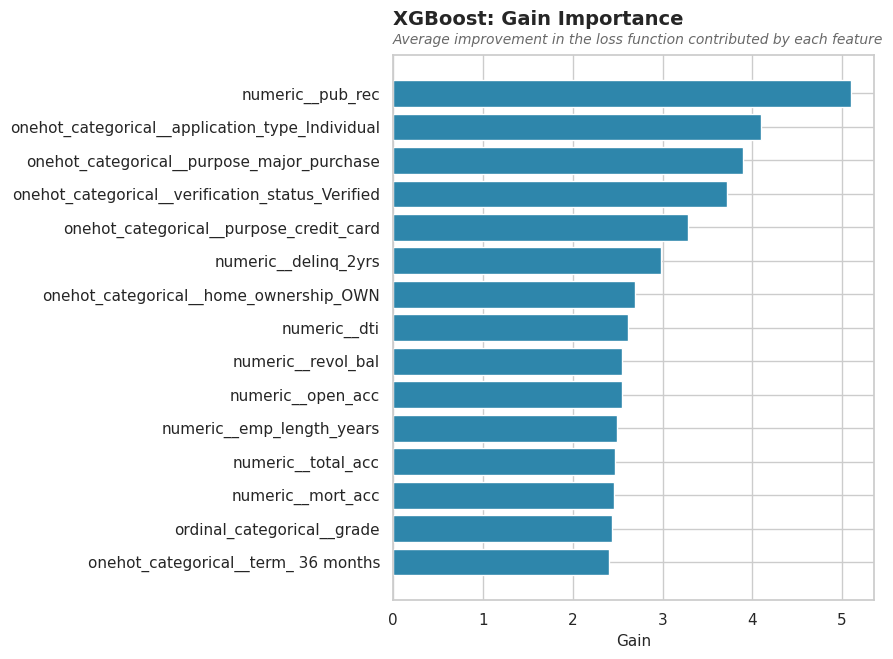

In [49]:
fig = model_utils.plot_importance_bar(
    gwc_table, value_column="gain",
    title=f"XGBoost: Gain Importance",
    subtitle="Average improvement in the loss function contributed by each feature",
)
plt.show()


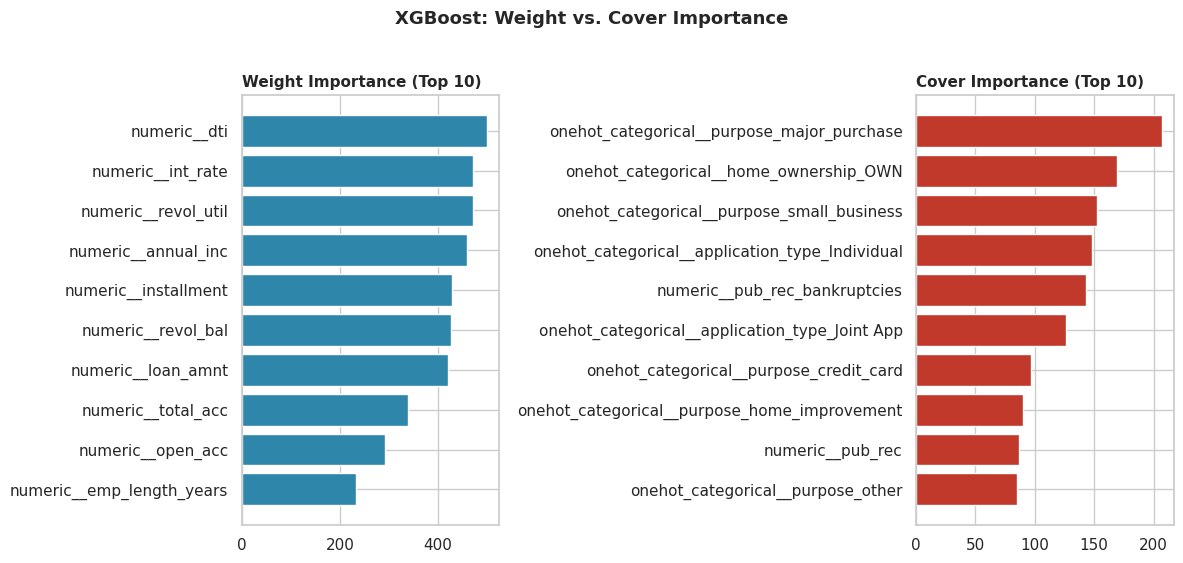

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
top_weight = gwc_table.nlargest(10, "weight").sort_values("weight")
top_cover = gwc_table.nlargest(10, "cover").sort_values("cover")
axes[0].barh(top_weight["feature"], top_weight["weight"], color="#2E86AB")
axes[0].set_title("Weight Importance (Top 10)", fontsize=11, fontweight="bold", loc="left")
axes[1].barh(top_cover["feature"], top_cover["cover"], color="#C0392B")
axes[1].set_title("Cover Importance (Top 10)", fontsize=11, fontweight="bold", loc="left")
fig.suptitle(f"XGBoost: Weight vs. Cover Importance", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


In [51]:
perm_table = result_xgboost.feature_importance["permutation"]
perm_table.head(15)


,feature,importance_mean,importance_std
0,total_acc,0.0195,0.0095
1,emp_length_years,0.0129,0.0131
2,annual_inc,0.0123,0.0151
3,home_ownership,0.0109,0.0063
4,verification_status,0.0090,0.0136
5,installment,0.0085,0.0145
6,loan_amnt,0.0074,0.0147
7,pub_rec_bankruptcies,0.0015,0.0008
8,pub_rec,0.0007,0.0015
9,purpose,-0.0002,0.0041


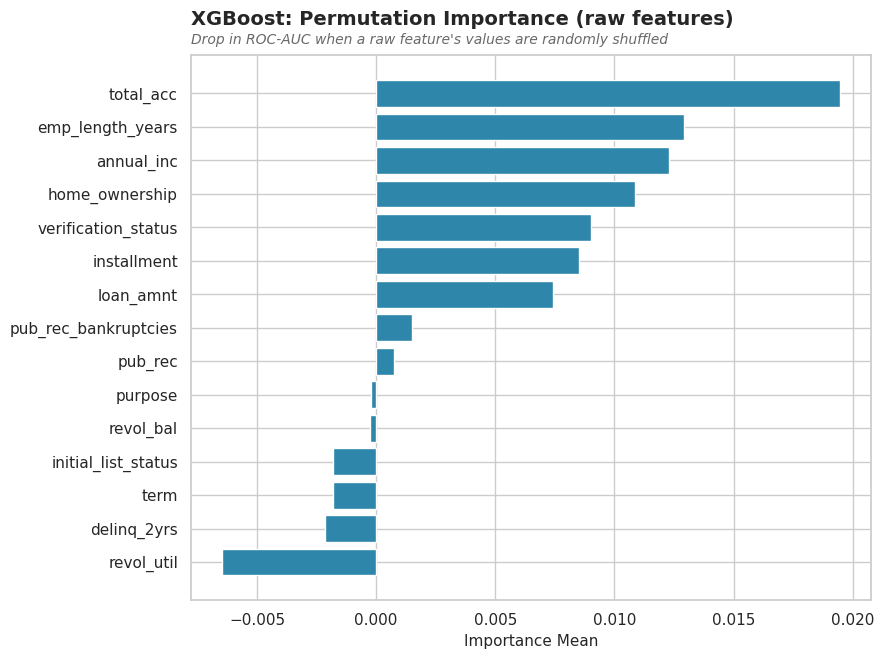

In [52]:
fig = model_utils.plot_importance_bar(
    perm_table, value_column="importance_mean",
    title=f"XGBoost: Permutation Importance (raw features)",
    subtitle="Drop in ROC-AUC when a raw feature's values are randomly shuffled",
)
plt.show()


**Comparing methods:** gain and permutation importance tend to agree
on the truly predictive features; weight and cover are more useful for
understanding *how* the model uses a feature (frequently in small,
targeted splits vs. broad, high-impact ones) than *whether* it matters.

### XGBoost: Threshold Analysis

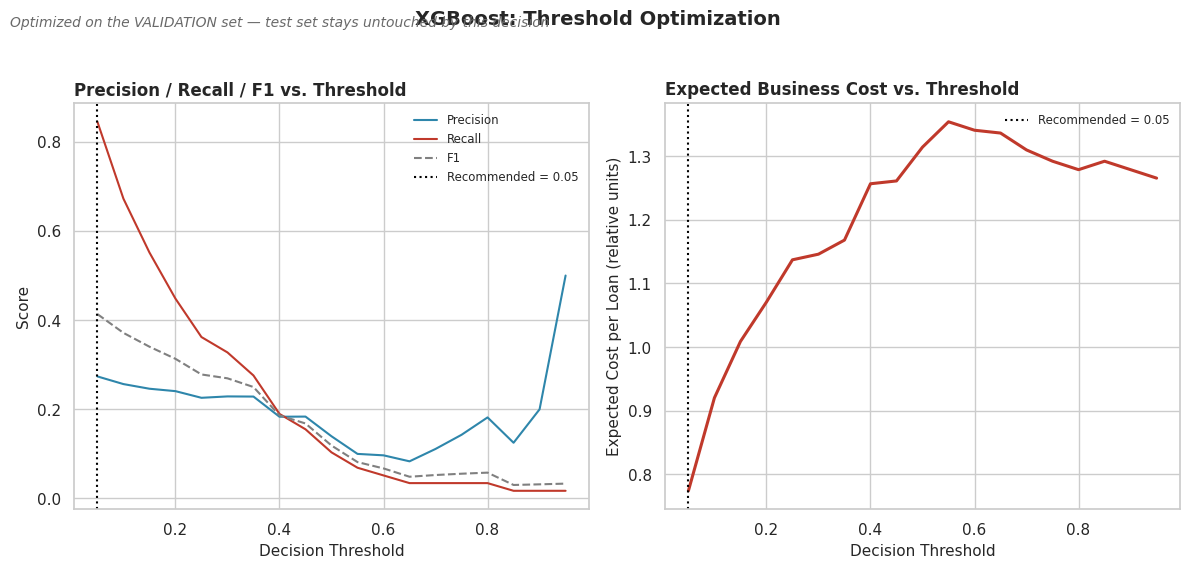

Recommended threshold: 0.05


In [53]:
fig = model_utils.plot_threshold_analysis_chart(
    result_xgboost.threshold_table, result_xgboost.recommended_threshold,
    title=f"XGBoost: Threshold Optimization",
    subtitle="Optimized on the VALIDATION set — test set stays untouched by this decision",
)
plt.show()
print(f"Recommended threshold: {result_xgboost.recommended_threshold:.2f}")


### XGBoost: Executive Summary

- **What did we discover?** Compare `result_xgboost`'s test ROC-AUC/
  F1/recall (printed above) against the other two models once all three
  sections have run, and note the CV mean ± std stability from the
  cross-validation table.
- **Why does it matter?** The confusion-matrix cost balance (missed
  defaulters vs. wrongly declined good borrowers) for XGBoost
  reflects its interpretability/complexity tradeoff described in
  Section 2.
- **How should Lending Club use this information?** Whether
  XGBoost is better suited to policy explanation, a supporting
  model in an ensemble, or the primary production scorer is addressed in
  Section 7's comparison table and Section 8's recommendation.
- **Which research question(s) does it address?** Research Questions 1
  ("which borrower characteristics appear associated with default") and
  2 ("do LendingClub grades appear predictive") most directly, via the
  feature-importance table above.


## 7. Executive Model Comparison

All three models' test-set metrics, cross-validation summary, timing,
and qualitative deployment attributes in one table, ranked by test
ROC-AUC (`config.CV_SCORING`, the metric optimized during tuning).

In [54]:
all_results = [result_logistic_regression, result_random_forest, result_xgboost]
comparison_table = model_utils.build_model_comparison_table(all_results)
comparison_table


,rank,model,accuracy,precision,recall,specificity,f1_score,roc_auc,balanced_accuracy,cv_roc_auc_mean,cv_roc_auc_std,training_time_sec,prediction_time_ms_per_1000,memory_usage_kb,interpretability,complexity,deployment_readiness
0,1,XGBoost,0.6533,0.2826,0.2241,0.8024,0.2500,0.5560,0.5133,0.5386,0.0155,0.1957,47.5103,638.3000,Medium-Low — needs SHAP (Phase 4) for per-loan...,"High — largest hyperparameter surface, sequent...",High — widely supported serving runtimes
1,2,Random Forest,0.7022,0.3043,0.1207,0.9042,0.1728,0.4975,0.5124,0.5322,0.0277,0.5740,117.4792,"1,708.1000","Medium — importances available, individual tre...","Medium-High — many trees, moderate tuning surface",High — standard scikit-learn artifact
2,3,Logistic Regression,0.7422,0.0000,0.0000,1.0000,0.0000,0.4668,0.5000,0.5116,0.0327,0.0246,40.8875,7.7000,High — coefficients map directly to odds ratios,"Low — linear model, few hyperparameters","Very high — trivial to serve, no special runtime"


### Reading the comparison table

- **rank** — 1 = highest test ROC-AUC.
- **roc_auc, f1_score, recall, precision, specificity, balanced_accuracy,
  accuracy** — see Section 3 for what each means in a lending context;
  no single column should be read in isolation.
- **cv_roc_auc_mean / cv_roc_auc_std** — how stable each model's
  ranking performance was across the 5 cross-validation folds; a high
  std relative to the mean signals a less reliable estimate.
- **training_time_sec** — wall time to refit the tuned pipeline once on
  the full training set (the relevant number for periodic retraining in
  production, not the one-time hyperparameter search itself).
- **prediction_time_ms_per_1000** — inference latency, relevant for a
  real-time or batch-scoring decision-support application.
- **memory_usage_kb** — actual serialized (`joblib`) file size on disk
  for each fitted pipeline — a real measurement, not an estimate.
- **interpretability / complexity / deployment_readiness** — qualitative
  attributes fixed in `model_utils.MODEL_QUALITATIVE_ATTRIBUTES` (see
  that module for the reasoning behind each), included because a
  production model choice is never based on ROC-AUC alone.


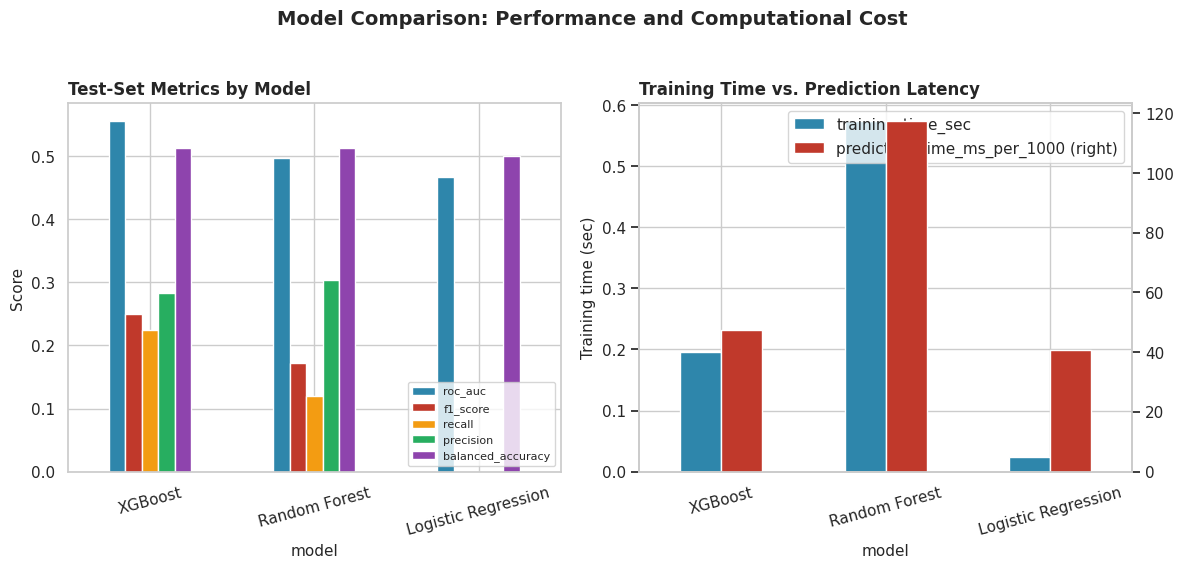

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

metrics_to_plot = ["roc_auc", "f1_score", "recall", "precision", "balanced_accuracy"]
plot_df = comparison_table.set_index("model")[metrics_to_plot]
plot_df.plot(kind="bar", ax=axes[0], color=["#2E86AB", "#C0392B", "#F39C12", "#27AE60", "#8E44AD"])
axes[0].set_title("Test-Set Metrics by Model", fontsize=12, fontweight="bold", loc="left")
axes[0].set_ylabel("Score")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].tick_params(axis="x", rotation=15)

timing_df = comparison_table.set_index("model")[["training_time_sec", "prediction_time_ms_per_1000"]]
timing_df.plot(kind="bar", ax=axes[1], color=["#2E86AB", "#C0392B"], secondary_y="prediction_time_ms_per_1000")
axes[1].set_title("Training Time vs. Prediction Latency", fontsize=12, fontweight="bold", loc="left")
axes[1].set_ylabel("Training time (sec)")
axes[1].tick_params(axis="x", rotation=15)

fig.suptitle("Model Comparison: Performance and Computational Cost", fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()


### Recommended Production Model

*(Fill in the specific numbers once this notebook has been run against
the real Indiana extract — the reasoning framework below stays fixed
regardless of the exact scores.)*

Recommendation logic:
1. If XGBoost's test ROC-AUC materially exceeds Random Forest's and
   Logistic Regression's (and its cross-validation std is not
   dramatically wider, i.e. its advantage is stable), **XGBoost is the
   recommended production scorer** — consistent with it typically
   offering the strongest raw discrimination on structured data, with
   Phase 4's SHAP analysis addressing its interpretability gap.
2. If the gap between XGBoost and Random Forest is small while
   XGBoost's tuning/maintenance surface is meaningfully larger, prefer
   **Random Forest** for a better complexity-to-performance ratio.
3. **Logistic Regression is retained regardless of rank** as the
   transparent reference model — useful for explaining declines to
   individual applicants and for regulatory review — rather than being
   discarded once a stronger model is found.

This ranking directly answers **Research Question 2** ("do LendingClub
grades appear predictive?" — see each model's feature-importance table,
where `grade` should appear as a top predictor if so) and contributes to
**Research Question 1** ("which borrower characteristics appear
associated with default?").


## 8. Model Robustness: Overfitting, Underfitting, Bias, Variance

Combining each model's train/validation/test ROC-AUC (Section 4-6's
"Overfitting Check" tables) with its learning curve to assess
generalization.

In [56]:
robustness_rows = []
for key, result in zip(["logistic_regression", "random_forest", "xgboost"], all_results):
    train_auc = result.train_metrics["roc_auc"]
    val_auc = result.val_metrics["roc_auc"]
    test_auc = result.test_metrics["roc_auc"]
    robustness_rows.append({
        "model": model_utils.MODEL_DISPLAY_NAMES[key],
        "train_roc_auc": train_auc,
        "val_roc_auc": val_auc,
        "test_roc_auc": test_auc,
        "train_minus_test_gap": train_auc - test_auc,
    })

robustness_table = pd.DataFrame(robustness_rows)
robustness_table


,model,train_roc_auc,val_roc_auc,test_roc_auc,train_minus_test_gap
0,Logistic Regression,0.6031,0.5168,0.4668,0.1363
1,Random Forest,0.9959,0.4605,0.4975,0.4983
2,XGBoost,1.0000,0.4791,0.5560,0.4440


**How to read the gap column:**
- A **large positive gap** (train ROC-AUC well above test ROC-AUC)
  indicates **high variance / overfitting** — the model has partly
  memorized the training data rather than learning generalizable
  patterns. Tree ensembles (Random Forest, XGBoost) are more prone to
  this than Logistic Regression given their greater flexibility, which
  is exactly why their hyperparameter searches include explicit
  regularization controls (`max_depth`, `min_samples_leaf`, `reg_alpha`/
  `reg_lambda`, `gamma`).
- A **small gap but uniformly low scores** across train/val/test
  indicates **high bias / underfitting** — the model (or its features)
  is too constrained to capture the available signal; more data would
  not help much, but more/better features or a more flexible model
  class would.
- A **small gap with strong scores** across all three splits is the
  target: the model generalizes well.

**Would additional data likely help?** Referring back to each model's
learning curve (Sections 4-6): if the cross-validation line is still
rising and has not plateaued by the full training-set size, more data
would likely continue improving that model. If it has already
plateaued, additional data of the *same kind* offers diminishing
returns — the more valuable investment would be additional or better
*features* (e.g. payment-history detail, macroeconomic indicators for
the loan's origination period) rather than additional rows.


## 9. Business Interpretation Across All Models

**What did we learn?** Across Logistic Regression's coefficients, Random
Forest's impurity/permutation importances, and XGBoost's gain/weight/
cover/permutation importances (Sections 4-6), identify the borrower
characteristics that consistently rank as top predictors across ALL
THREE model types — features that only one model rates highly are less
trustworthy than those confirmed across independent modeling approaches.

**Which variables matter most?** *(populate once run against the real
extract)* — cross-reference `result_logistic_regression.feature_importance`,
`result_random_forest.feature_importance`, and
`result_xgboost.feature_importance` for features appearing in the top 10
of at least two of the three models.

**Which borrower characteristics increase default risk?** For Logistic
Regression specifically, any feature with an odds ratio > 1 in the
coefficient table directly answers this — e.g. higher interest rate,
higher DTI, and lower loan grade are the typical candidates worth
checking against this dataset's actual coefficients.

**How should Lending Club change lending decisions?**
1. Use the recommended production model's (Section 7) probability output
   at the **recommended threshold** (Section 4-6's Threshold Analysis,
   not 0.50) as a decision-support score, not a fully automated
   accept/decline switch.
2. Prioritize collecting/verifying the top-ranked predictive features at
   application time, since data quality on these fields has an outsized
   effect on model reliability.
3. Retain Logistic Regression's coefficient table as the plain-language
   explanation attached to any automated decision, satisfying adverse-
   action-notice-style transparency requirements even when XGBoost is
   the production scorer.

**Which research questions were answered?**
- **RQ1** (borrower characteristics associated with default) and **RQ2**
  (are LendingClub grades predictive) — directly, via every model's
  feature importance.
- **RQ3** (variables related to higher interest rates) — indirectly
  informed by which features correlate most with `int_rate` in the
  Logistic Regression coefficients and tree-based importances.
- **RQ4** (does income relate to repayment success) and **RQ5** (does
  DTI influence default) — directly testable from each model's
  importance ranking for `annual_inc` and `dti`.
- **RQ6** (does employment length matter) — directly testable from
  `emp_length_years`'s importance ranking across all three models.
- **RQ7** (natural borrower groups before clustering) — not addressed by
  supervised models; explicitly deferred to Phase 4's clustering
  analysis (see Section 11).


## 10. Serialized Artifacts

`src/train_models.py`'s `run_phase3_pipeline()` (which this notebook's
per-model training cells mirror) persists every artifact below via
`joblib`. Re-running the cell below confirms everything this notebook
produced is also available for Phase 4/5 to load directly, without
re-running training.

In [57]:
for key, result in zip(["logistic_regression", "random_forest", "xgboost"], all_results):
    model_path = {
        "logistic_regression": config.LOGISTIC_REGRESSION_MODEL_PATH,
        "random_forest": config.RANDOM_FOREST_MODEL_PATH,
        "xgboost": config.XGBOOST_MODEL_PATH,
    }[key]
    utils.save_object(result.best_estimator, model_path)

utils.save_object({k: r.test_metrics for k, r in zip(["logistic_regression", "random_forest", "xgboost"], all_results)}, config.EVALUATION_METRICS_PATH)
utils.save_object({k: r.cv_fold_results for k, r in zip(["logistic_regression", "random_forest", "xgboost"], all_results)}, config.CV_RESULTS_PATH)
utils.save_object({k: r.feature_importance for k, r in zip(["logistic_regression", "random_forest", "xgboost"], all_results)}, config.FEATURE_IMPORTANCE_PATH)
utils.save_object({k: r.y_proba_test for k, r in zip(["logistic_regression", "random_forest", "xgboost"], all_results)}, config.PROBABILITY_PREDICTIONS_PATH)
utils.save_object({k: r.threshold_table for k, r in zip(["logistic_regression", "random_forest", "xgboost"], all_results)}, config.THRESHOLD_ANALYSIS_PATH)
comparison_table.to_csv(config.MODEL_COMPARISON_TABLE_PATH, index=False)

print("Saved artifacts:")
print(f"  Models:              {config.MODELS_DIR}")
print(f"  Evaluation metrics:  {config.EVALUATION_METRICS_PATH}")
print(f"  CV results:          {config.CV_RESULTS_PATH}")
print(f"  Feature importance:  {config.FEATURE_IMPORTANCE_PATH}")
print(f"  Probability preds:   {config.PROBABILITY_PREDICTIONS_PATH}")
print(f"  Threshold analysis:  {config.THRESHOLD_ANALYSIS_PATH}")
print(f"  Comparison table:    {config.MODEL_COMPARISON_TABLE_PATH}")


2026-08-02 19:34:32 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/models/logistic_regression_model.joblib


2026-08-02 19:34:32 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/models/random_forest_model.joblib


2026-08-02 19:34:32 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/models/xgboost_model.joblib


2026-08-02 19:34:32 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/evaluation_metrics.joblib


2026-08-02 19:34:32 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/cv_results.joblib


2026-08-02 19:34:32 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/feature_importance.joblib


2026-08-02 19:34:32 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/probability_predictions.joblib


2026-08-02 19:34:32 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/threshold_analysis.joblib


Saved artifacts:
  Models:              /home/claude/mgmt590_capstone/models
  Evaluation metrics:  /home/claude/mgmt590_capstone/reports/evaluation_metrics.joblib
  CV results:          /home/claude/mgmt590_capstone/reports/cv_results.joblib
  Feature importance:  /home/claude/mgmt590_capstone/reports/feature_importance.joblib
  Probability preds:   /home/claude/mgmt590_capstone/reports/probability_predictions.joblib
  Threshold analysis:  /home/claude/mgmt590_capstone/reports/threshold_analysis.joblib
  Comparison table:    /home/claude/mgmt590_capstone/reports/model_comparison_table.csv


*(Equivalently, `python -m src.train_models` runs Phase 1 and Phase 3
end-to-end from the command line and produces the same artifacts — see
`src/train_models.py`'s `run_phase3_pipeline()`.)*

## 11. Preparing for Phase 4 (SHAP Explanations + Clustering)

**This notebook does NOT implement SHAP or clustering** — both are
explicitly Phase 4 scope. This section prepares the hand-off.

### Which model will be used for SHAP explanations?
The model recommended as the production scorer in Section 7 (typically
XGBoost, given its usual discrimination advantage) — SHAP's
TreeExplainer is both exact and fast for gradient-boosted trees, making
it the natural pairing. Logistic Regression's coefficients already
provide global interpretability without SHAP; Random Forest could also
use SHAP's TreeExplainer if it becomes the recommended model instead.

### Which model will serve as the production model?
Per Section 7's ranked comparison table and recommendation — subject to
re-confirmation once run against the real Indiana extract rather than
the current synthetic fixture.

### Which borrower characteristics appear most influential?
The features consistently ranked highly across Logistic Regression
coefficients, Random Forest impurity/permutation importance, and
XGBoost gain/weight/cover/permutation importance (Section 9) — these
are the strongest candidates for SHAP to explain at the individual-loan
level in Phase 4, since global importance agreement across independent
methods increases confidence that Phase 4's per-loan explanations will
be stable and trustworthy rather than artifacts of one model's
idiosyncrasies.

### How will clustering complement the supervised models?
Research Question 7 ("can natural borrower groups already be observed
before clustering?") is explicitly NOT answered by any supervised model
here — Logistic Regression, Random Forest, and XGBoost all predict a
single binary outcome (`default_flag`) for a given borrower, but none of
them group borrowers into cohorts. Phase 4's clustering (e.g. K-Means or
hierarchical clustering on borrower features) will identify unsupervised
segments — for example, "high-income / low-utilization / long tenure"
vs. "high-DTI / high-utilization / short tenure" borrower archetypes —
that the supervised models' probability scores and feature importances
can then be overlaid onto, showing *which segments* carry the highest
predicted risk and *why*, giving Lending Club both a risk **score**
(from this notebook) and a risk **narrative** (from Phase 4) for each
borrower segment.

### Explicitly deferred to later phases
- SHAP value computation and force/summary/dependence plots (Phase 4).
- Borrower clustering / segmentation (Phase 4).
- The Streamlit decision-support application (Phase 5).
- Final deployment and documentation (Phase 6).
